# Imports

In [19]:
import sys
import os

#sys.path.append("/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/")
#sys.path.insert(0, "/user/work/ef17148/oldstuff/ef17148/.conda/envs/graphnet/lib/python3.8/site-packages/")

import cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize, TwoSlopeNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable  # for neat colorbar placement



import numpy as np

#sys.path.insert(0, "/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/")

#sys.path.insert(0,"/software/local/languages/miniforge3/envs/tensorflow/lib/python3.12/site-packages")

sys.path.insert(0,"/software/local/languages/miniforge3/envs/elena/lib/python3.12/site-packages/")

sys.path.insert(0,"/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages")

sys.path.insert(0, "/user/work/kr21883/")


print(sys.path)

import torch
import os
import pickle
import einops


import xarray as xr
from glob import glob
from scipy.stats import pearsonr
import matplotlib.animation as animation

#import plenoptic as po

#sys.path.insert(0, "/user/work/kr21883/GCN/graphnet/")
from graphnet_LPDM_emulator.model.layers.encoder import *
from graphnet_LPDM_emulator.model.layers.decoder import *
from graphnet_LPDM_emulator.model.layers.processor import *
from graphnet_LPDM_emulator.model.layers.graph_net_block import *
from graphnet_LPDM_emulator.model.data.dataloader_graphnet import *
from graphnet_LPDM_emulator.model.data.load_data import *
from graphnet_LPDM_emulator.model.forecast import GraphSatelliteForecaster
from graphnet_LPDM_emulator.model.loss_functions import *
from graphnet_LPDM_emulator.model.evaluation import *
from graphnet_LPDM_emulator.model.metrics_and_figures import *

import torch.optim as optim
from sklearn.metrics import mean_squared_error, r2_score
import time
from datetime import datetime
import json
import argparse

import random

%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import timeit

['/user/work/kr21883/', '/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages', '/software/local/languages/miniforge3/envs/elena/lib/python3.12/site-packages/', '/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages', '/software/local/languages/miniforge3/envs/elena/lib/python3.12/site-packages/', '/user/work/kr21883/', '/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages', '/software/local/languages/miniforge3/envs/elena/lib/python3.12/site-packages/', '/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python312.zip', '/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12', '/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/lib-dynload', '', '/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages']
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Functions

In [2]:
def plot_mean_with_uncertainty(ax, models, key, label=None, color=None, max_len=100):
    ### For the training metrics
    values = []
    for mod in models:
        if key in mod:
            data = mod[key]
            if isinstance(data, dict):
                data = data["R2"]
            values.append(np.array(data[:max_len]))
    
    if not values:
        return

    values = np.stack(values)  # shape: (num_models, time)
    mean = np.mean(values, axis=0)
    std = np.std(values, axis=0)

    x = np.arange(len(mean))
    ax.plot(x, mean, label=label, color=color)
    ax.fill_between(x, mean - std, mean + std, alpha=0.3, color=color)


# Local helper function to save inside summary_outputs
def save_path(filename):
    return os.path.join(summary_dir, filename)

# For animated visualation of uncertainty
def animate_dataarray(da, title_prefix, filename, cmap="viridis", interval=300, vmin=None, vmax=None, save_dir="."):
    """
    Creates and saves an animation of a spatio-temporal xarray.DataArray.

    Parameters:
    - da: xarray.DataArray with dimensions including 'time', 'lat', and 'lon'
    - title_prefix: string, e.g., 'Mean Prediction'
    - filename: string, e.g., 'mean_prediction.gif'
    - cmap: matplotlib colormap string
    - interval: int, milliseconds between frames
    - vmin, vmax: floats, fixed colorbar limits (optional)
    - save_dir: directory to save the gif in
    """

    fig, ax = plt.subplots()
    da0 = da.isel(time=0)
    img = da0.plot(ax=ax, cmap=cmap, add_colorbar=False, vmin=vmin, vmax=vmax)
    cbar = plt.colorbar(img, ax=ax)
    cbar.set_label(title_prefix)

    def update(frame_idx):
        ax.clear()
        da_frame = da.isel(time=frame_idx)
        da_frame.plot(ax=ax, cmap=cmap, add_colorbar=False, vmin=vmin, vmax=vmax)
        ax.set_title(f"{title_prefix} - Time {frame_idx}")
        return ax

    ani = animation.FuncAnimation(fig, update, frames=da.sizes["time"], interval=interval)
    output_path = os.path.join(save_dir, filename)
    ani.save(output_path, writer="pillow")
    plt.close()
    print(f"Saved animation: {output_path}")


def get_all_mole_fractions(flux_type="uniform"):
    if flux_type == "uniform":
        save_file = "mole_fractions.npz"
    elif flux_type == "actual":
        save_file = "mole_fractions_above_baseline.npz"

    if os.path.exists(save_file):
        print(f"Loading cached mole fraction arrays from {save_file}...")
        data = np.load(save_file)
        pred_mole_fractions = data["pred"]
        true_mole_fractions = data["true"]
        print(f"Loaded shapes: pred={pred_mole_fractions.shape}, true={true_mole_fractions.shape}")

    else:
        pred_mole_fractions = []
        true_mole_fractions = []

        for name in model_names:
            print(name)

            mod = ModelEv(
                name,
                size=50,
                validation_set="0[1-3]",
                test_set="*",
                val_year="2016",
                test_year="2016",
                check_validation_overlap=True,
                path_to_files="/group/chemistry/acrg/ef17148/trained_satellite_models/"
            )
            mod.get_adjusted_models(which="thr_only")

            if flux_type == "uniform":
                try:
                    mod.get_fluxes()
                    pred = mod.pred_fluxes.get("thr", None)
                    true = getattr(mod, "true_flux", None)

                    window_n = 5
                    window_size = 200
                    plt.plot(mod.true_flux[window_n*window_size:(1+window_n)*window_size])
                    plt.plot(mod.pred_fluxes["thr"][window_n*window_size:(1+window_n)*window_size])
                    plt.show()

                    if pred is not None and true is not None:
                        pred_mole_fractions.append(pred)
                        true_mole_fractions.append(true)
                    else:
                        print(f"Skipping model {mod.model_name} — fluxes missing")

                except Exception as e:
                    print(f"Error processing model {mod.model_name}: {e}")

            elif flux_type == "actual":
                # Load the Brazil map of fluxes
                brazil_fluxes = load_default_brazil_emissions()

                # Load the true footprints and select same timepoints as testing set
                true_fps = load_fps("/group/chemistry/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_2016*.nc")
                true_fps = true_fps.sel(time=mod.preds_test.time)

                # Cut flux to match footprint release locations
                cut_flux = cut_emissions_data(brazil_fluxes, true_fps, 50)
                cut_flux = cut_flux.transpose([2, 0, 1])

                # Compute mole fraction with cut data
                mod.get_fluxes(cut_flux)

                pred = mod.pred_fluxes.get("thr", None)
                true = getattr(mod, "true_flux", None)

                # Optional quick visual check
                window_n = 3
                window_size = 200
                plt.plot(1e9 * mod.true_flux[window_n*window_size:(1+window_n)*window_size])
                plt.plot(1e9 * mod.pred_fluxes["thr"][window_n*window_size:(1+window_n)*window_size])
                plt.ylabel("ppb")
                plt.show()

                if pred is not None and true is not None:
                    pred_mole_fractions.append(pred)
                    true_mole_fractions.append(true)
                else:
                    print(f"Skipping model {mod.model_name} — mole_fractions missing")

        # Stack and save
        pred_mole_fractions = np.stack(pred_mole_fractions, axis=0)  # shape: (models, time)
        true_mole_fractions = np.stack(true_mole_fractions, axis=0)
        np.savez_compressed(save_file, pred=pred_mole_fractions, true=true_mole_fractions)

        print(f"Saved mole fraction arrays to {save_file}")

    return pred_mole_fractions, true_mole_fractions

def plot_mole_fraction(pred_mole_fractions, true_mole_fractions, flux_type="uniform", window_size=200):
    window_n = 5
    start = window_n * window_size
    end = (window_n + 1) * window_size

    pred_mole_fractions = np.stack(pred_mole_fractions, axis=0)  # shape: (n_models, time)
    true_mole_fractions = np.stack(true_mole_fractions, axis=0)

    for i in range(pred_mole_fractions.shape[0]):
        plt.plot(pred_mole_fractions[i, start:end], alpha=0.5, label=f"Model {i+1}")

    plt.plot(true_mole_fractions[0, start:end], alpha=0.5, color="black", label="True Mole Fraction")
    plt.legend()
    if flux_type == "uniform":
        plt.title("Mole fraction with uniform flux field")
        plt.savefig(save_path("flux_timeseries_overlay.png"))
    elif flux_type == "actual":
        plt.title("Mole fraction with true flux field (above baseline mole fractions)")
        plt.savefig(save_path("flux_timeseries_overlay_truefp.png"))
    plt.show()

def compute_mole_fraction_stats(pred_mole_fractions, true_mole_fractions):
    mean_mole_fraction = np.mean(pred_mole_fractions, axis=0)  # shape: (time,)
    std_mole_fraction = np.std(pred_mole_fractions, axis=0)    # shape: (time,)
    mean_true_mole_fraction = np.mean(true_mole_fractions, axis=0)  # Optional: mean ground truth across models
    normalised_mean_mole_fraction = mean_mole_fraction/mean_true_mole_fraction # normalised to the true footprint magnitude
    normalised_std_mole_fraction = std_mole_fraction/mean_true_mole_fraction # normalised to the true footprint magnitude

    return mean_mole_fraction, std_mole_fraction, mean_true_mole_fraction, normalised_mean_mole_fraction, normalised_std_mole_fraction

def plot_mole_fraction_uncertainty(pred_mole_fractions, true_mole_fractions, n_steps = 200, flux_type="uniform", plot="mean"):
    # Define number of time steps to plot
    
    mean_mole_fraction, std_mole_fraction, mean_true_mole_fraction, normalised_mean_mole_fraction, normalised_std_mole_fraction = compute_mole_fraction_stats(pred_mole_fractions, true_mole_fractions)

    # Slice data arrays
    mean_mole_fraction_subset = mean_mole_fraction[:n_steps]
    std_mole_fraction_subset = std_mole_fraction[:n_steps]
    mean_true_mole_fraction_subset = mean_true_mole_fraction[:n_steps]

    time = np.arange(n_steps)

    # Plot
    plt.figure(figsize=(10, 5))

    # Plot mean predicted mole_fraction with uncertainty band
    if plot == "CV":
        plt.plot(time, std_mole_fraction_subset/mean_mole_fraction_subset, label="Uncertainty of Predicted Mole Fraction", color="tab:blue")
    if plot == "mean":
        plt.plot(time, mean_mole_fraction_subset, label="Mean Predicted Mole Fraction", color="tab:blue")
        plt.fill_between(time, 
                        mean_mole_fraction_subset + std_mole_fraction_subset, 
                        mean_mole_fraction_subset - std_mole_fraction_subset, 
                        alpha=0.3, color="tab:blue", label="±1 SD")

    # Plot ground truth
    plt.plot(time, mean_true_mole_fraction_subset, label="Ground Truth", color="tab:red")
    plt.xlabel("Time Step")
    plt.ylabel("Mole Fraction")
    plt.legend()
    plt.grid(True)
    #plt.tight_layout()
    if flux_type == "uniform":
        plt.title(f"Predicted Mole Fraction (Uniform Flux) with Uncertainty (First {n_steps} Timesteps)")
        plt.savefig(save_path(f"mole_fraction_timeseries_uniform_uncertainty_{plot}.pdf"))
    elif flux_type == "actual":
        plt.title(f"Predicted Mole Fraction (True Flux, Above baseline) with Uncertainty (First {n_steps} Timesteps)")
        plt.savefig(save_path(f"mole_fraction_timeseries_true_flux_uncertainty_{plot}.pdf"))
    plt.show()

def plot_normalised_mole_fraction_uncertainty(pred_mole_fractions, true_mole_fractions, n_steps = 200, flux_type="uniform"):

    mean_mole_fraction, std_mole_fraction, mean_true_mole_fraction, normalised_mean_mole_fraction, normalised_std_mole_fraction = compute_mole_fraction_stats(pred_mole_fractions, true_mole_fractions)
    mean_mole_fraction_subset = mean_mole_fraction[:n_steps]
    std_mole_fraction_subset = std_mole_fraction[:n_steps]
    mean_true_mole_fraction_subset = mean_true_mole_fraction[:n_steps]
    normalised_mean_mole_fraction_subset = normalised_mean_mole_fraction[:n_steps]
    normalised_std_mole_fraction_subset = normalised_std_mole_fraction[:n_steps]

    time = np.arange(n_steps)

    # Create figure and main axis
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Plot mean predicted mole_fraction with uncertainty band on the left y-axis
    ax1.plot(time, std_mole_fraction_subset/mean_mole_fraction_subset, label="Uncertainty of Predicted Mole Fraction", color="tab:blue")
    #ax1.fill_between(time,
    #                normalised_mean_mole_fraction_subset - normalised_std_mole_fraction_subset,
    #                normalised_mean_mole_fraction_subset + normalised_std_mole_fraction_subset,
    #                alpha=0.3, color="tab:blue", label="±1 SD")

    ax1.set_xlabel("Time Step")
    ax1.set_ylabel("Predicted Mole Fraction Uncertainty", color="tab:blue")
    ax1.tick_params(axis='y', labelcolor="tab:blue")

    # Create a second y-axis on the right
    ax2 = ax1.twinx()

    # --- Align scales ---
    # Map the range of mean_true_subset to the left axis range
    left_min, left_max = normalised_mean_mole_fraction_subset.min(), normalised_mean_mole_fraction_subset.max()
    right_min, right_max = mean_true_mole_fraction_subset.min(), mean_true_mole_fraction_subset.max()

    # Scale ground truth so trends match left axis visually
    scaled_ground_truth = ((mean_true_mole_fraction_subset - right_min) / (right_max - right_min)) * (left_max - left_min) + left_min

    # Plot the scaled version on the same visual scale
    ax2.plot(time, mean_true_mole_fraction_subset, label="Ground Truth", color="tab:red")
    ax2.set_ylabel("Mole Fraction (ppb)", color="tab:red")
    ax2.tick_params(axis='y', labelcolor="tab:red")

    # Adjust right y-axis limits to match left axis visually
    #ax2.set_ylim(right_min, right_max)
    #ax1.set_ylim(left_min, left_max)

    # Title and grid
    ax1.grid(True)

    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    #plt.tight_layout()

    if flux_type == "uniform":
        plt.title(f"Mole Fraction Uncertainty (First {n_steps} Timesteps)")
        plt.savefig(save_path("21normalised_mole_fraction_timeseries_uncertainty.pdf"))
    elif flux_type == "actual":
        plt.title(f"Normalised Mole Fraction (True Flux, Above baseline) with Uncertainty (First {n_steps} Timesteps)")
        plt.savefig(save_path("normalised_mole_fraction_timeseries_uncertainty_above_baseline.png"))
    plt.show()

def find_extreme_mole_fraction_uncertainties(std_mole_fraction, top_n = 10):
    highest_uncertainty_indices = np.argsort(std_mole_fraction)[-top_n:][::-1]  # descending order
    lowest_uncertainty_indices = np.argsort(std_mole_fraction)[:top_n]  # descending order    

    print(f"--- {top_n} highest uncertainties: ---")
    for i in highest_uncertainty_indices:
        print(f"Time step {i}: std = {std_mole_fraction[i]:.4f}")

    print(f"--- {top_n} lowest uncertainties: ---")
    for i in lowest_uncertainty_indices:
        print(f"Time step {i}: std = {std_mole_fraction[i]:.4f}")

    return highest_uncertainty_indices, lowest_uncertainty_indices

def plot_extreme_mole_fraction_uncertainties(std_mole_fraction, top_n = 10):
    highest_uncertainty_indices, lowest_uncertainty_indices = find_extreme_mole_fraction_uncertainties(std_mole_fraction, top_n)

    time = np.arange(len(std_mole_fraction))
    plt.figure(figsize=(12, 5))
    plt.plot(time, std_mole_fraction, label="Std Dev (Uncertainty)", color="tab:blue")

    # Highlight top uncertain timesteps
    plt.scatter(highest_uncertainty_indices, std_mole_fraction[highest_uncertainty_indices], color="red", label="Most Uncertain Timesteps")
    plt.scatter(lowest_uncertainty_indices, std_mole_fraction[lowest_uncertainty_indices], color="green", label="Least Uncertain Timesteps")


    plt.title("Mole Fraction Prediction Uncertainty Over Time")
    plt.xlabel("Time Step")
    plt.ylabel("Standard Deviation")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(save_path(f"mole_fraction_timeseries_with_{top_n}_high_low_uncertainty.png"))
    plt.show()

def get_actual_mole_fractions(region):
    if region == "brazil":
        # loads the brazil map of fluxes
        brazil_fluxes = load_default_brazil_emissions()

        # load the true footprints to use the release_lat and release_lon,
        # and select the same timepoints as the testing set
        true_fps = load_fps("/group/chemistry/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_2016*.nc")
        true_fps = true_fps.sel(time=mod.preds_test.time)

        cut_flux = cut_emissions_data(brazil_fluxes, true_fps, 50)
        cut_flux = cut_flux.transpose([2,0,1])
        # now cut_flux is in the same shape as mod.pred_fluxes["thr"], so we can plot it
        mod.get_fluxes(cut_flux)

    else:
        print("Select another region, ie Brazil!")

    return mod



# Setup

In [3]:
variable_to_compare = "predictions" ####
disagreement_threshold = 0.003
epsilon = 1e-10  # for coefficient of variation to avoid division by zero

summary_dir = os.path.join("uncertainty/summary_outputs")
os.makedirs(summary_dir, exist_ok=True)

# time steps to plot
time_steps = [0,1,2]
single_time_step = 0

# List of model names
model_names = [
    "satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_B",
    "satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed5",
    "satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed100",
    "satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed33"
]

# Set global font sizes
plt.rcParams.update({
    "font.size": 14,       # base font size
    "axes.titlesize": 14,  # subplot titles
    "axes.labelsize": 14,  # x/y labels
    "legend.fontsize": 14, # legend
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
})

# 1. Comparing the losses across models

In [4]:
# four models to compare, each with a different seed 
# note that they all do have the same parameters even if the first is called _B, it was just an error in naming!!
loss_weiB = get_loss("satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_B")
loss_weiB["name"] = "Seed 34"
loss_weiC5 = get_loss("satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed5")
loss_weiC5["name"] = "Seed 5"
loss_weiC100 = get_loss("satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed100")
loss_weiC100["name"] = "Seed 100"
loss_weiC33 = get_loss("satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed33")
loss_weiC33["name"] = "Seed 33"

loading last checkpoint for satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_B
loading last checkpoint for satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed5
loading last checkpoint for satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed100
loading last checkpoint for satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed33


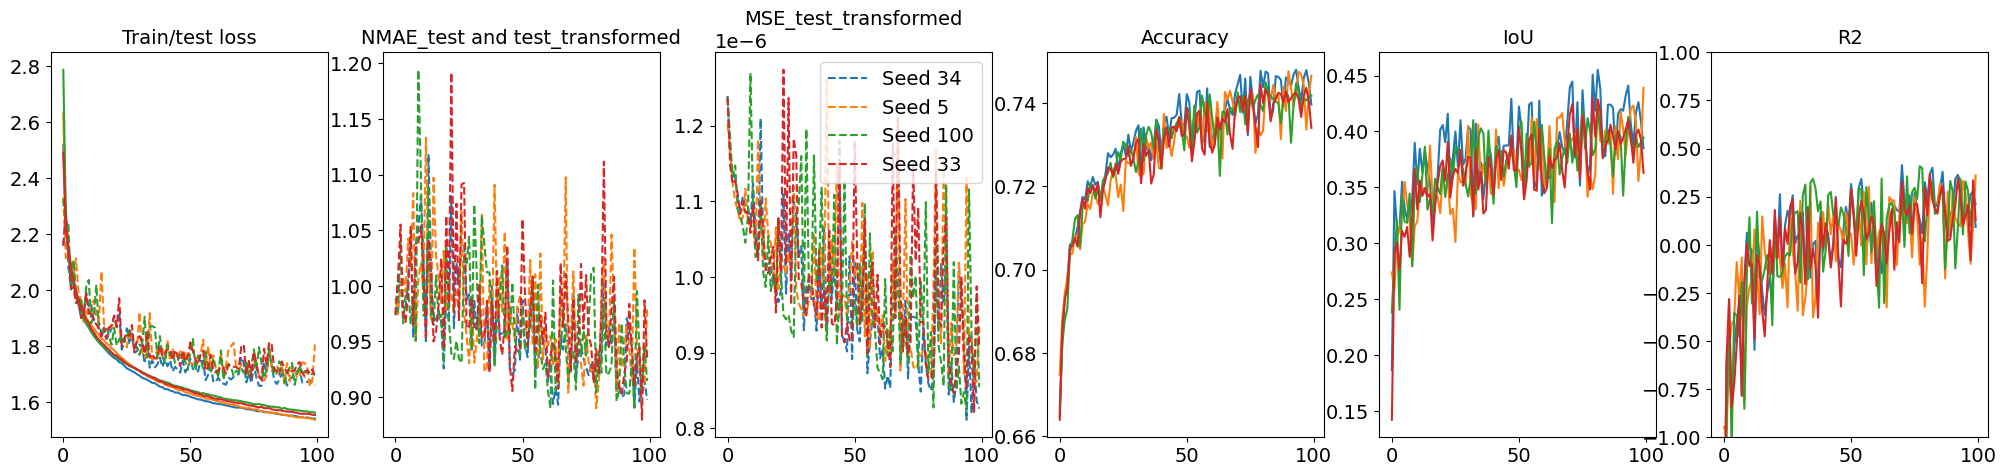

In [5]:
models_to_plot = [loss_weiB, loss_weiC5, loss_weiC100, loss_weiC33]
fig, ax = plt.subplots(1,6, figsize = (25,5))
for mod in models_to_plot:
    if "train" in list(mod.keys()):
        p, = ax[0].plot(mod["train"][:100])
        ax[0].plot(mod["test"][:100], "--", c=p.get_color()) 
    #if "NMAE_test" in list(mod.keys()):
    #    ax[1].plot(abs(np.array(mod["NMAE_test"])), c=p.get_color())  
    if "NMAE_test_transformed" in list(mod.keys()):
        ax[1].plot(abs(np.array(mod["NMAE_test_transformed"]))[:100], "--", c=p.get_color())       
    if "MSE_test_transformed" in list(mod.keys()):
        ax[2].plot(abs(np.array(mod["MSE_test_transformed"]))[:100], "--", c=p.get_color(), label=mod["name"])    
    if "accuracy" in list(mod.keys()):
        ax[3].plot(abs(np.array(mod["accuracy"]))[:100], c=p.get_color())    
    if "IoU" in list(mod.keys()):
        ax[4].plot(abs(np.array(mod["IoU"]))[:100], c=p.get_color())   
    if "flux_uniform" in list(mod.keys()):
        ax[5].plot(mod["flux_uniform"]["R2"][:100], c=p.get_color())   
    

ax[0].set_title("Train/test loss")
ax[1].set_title("NMAE_test and test_transformed")
ax[2].set_title("MSE_test_transformed")
ax[3].set_title("Accuracy")
ax[4].set_title("IoU")
ax[5].set_title("R2")
ax[5].set_ybound(-1,1)
ax[2].legend()
plt.savefig(save_path("model_training_uncertainty_plots_separate.png"))
plt.show()
plt.close()

## Aggregating: Plot mean + SD for training metrics

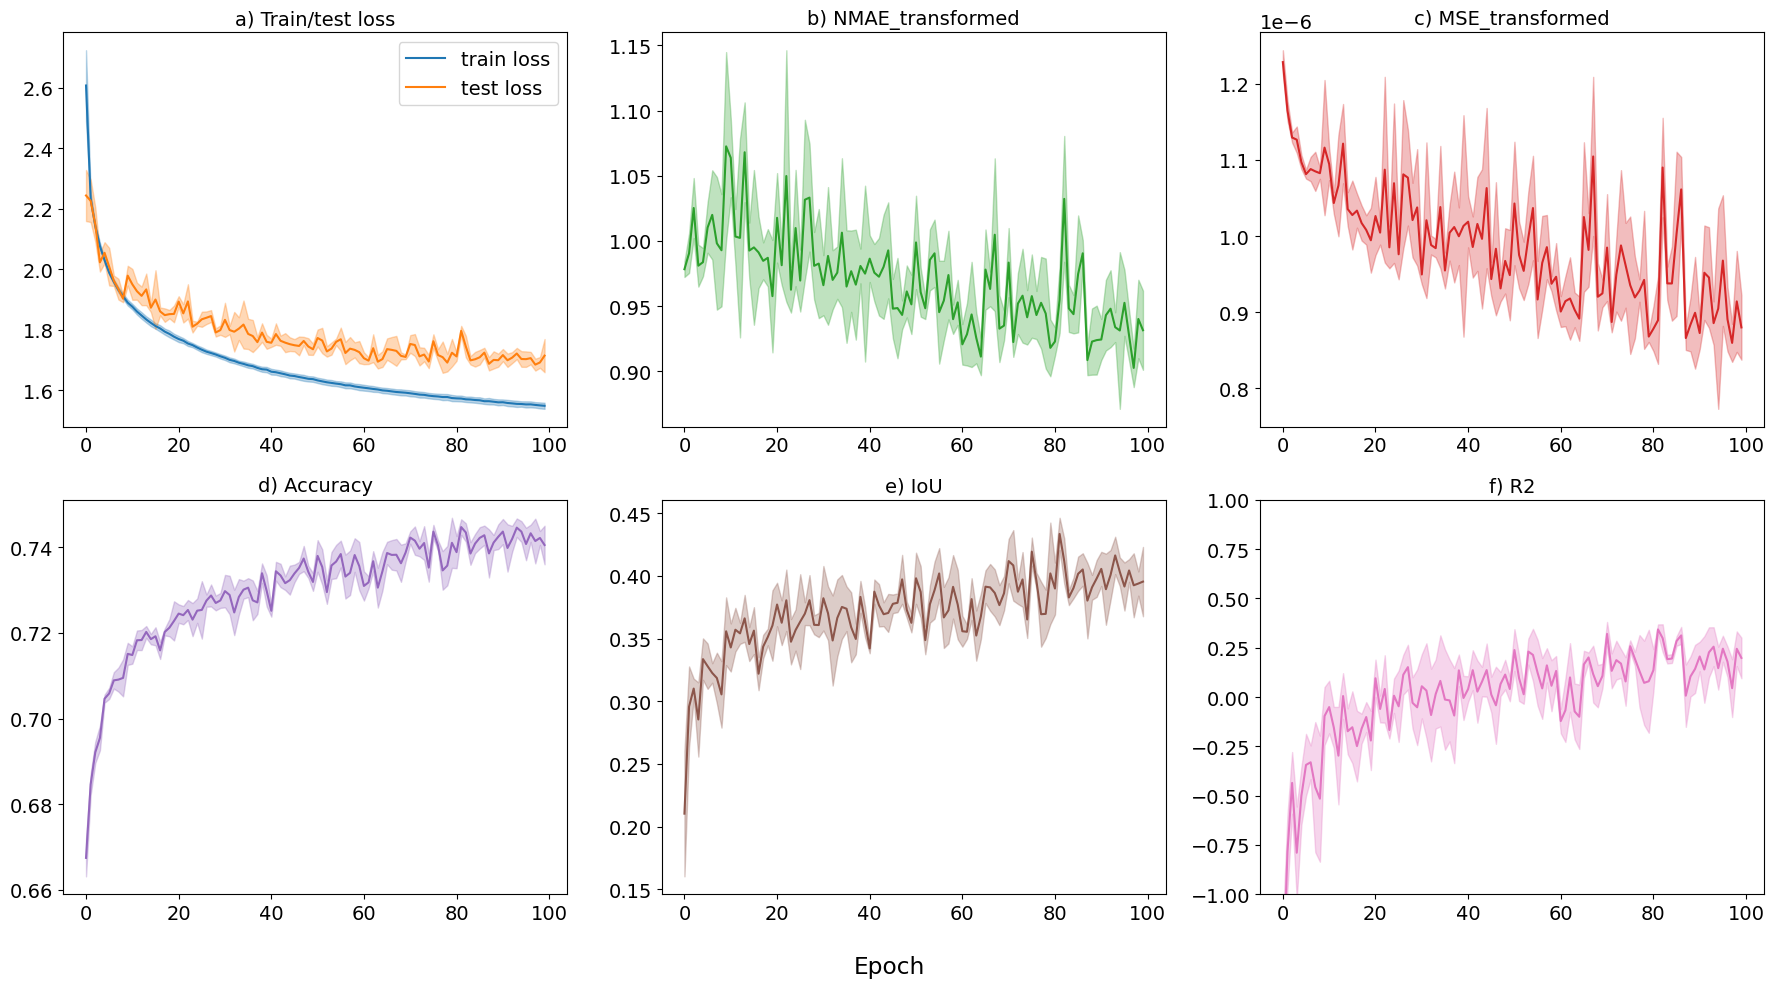

Saved model_training_uncertainty.pdf


In [16]:
colours = plt.cm.tab10.colors

# Create a new figure for uncertainty plots with 2 rows, 3 columns
fig2, ax2 = plt.subplots(2, 3, figsize=(18, 10))  # adjust figsize for better spacing

# Flatten so ax2[0]..ax2[5] works
ax2 = ax2.flatten()

plot_mean_with_uncertainty(ax2[0], models_to_plot, "train", label="train loss", color=colours[0])
plot_mean_with_uncertainty(ax2[0], models_to_plot, "test", label="test loss", color=colours[1])
ax2[0].set_title("a) Train/test loss")
ax2[0].legend()

plot_mean_with_uncertainty(ax2[1], models_to_plot, "NMAE_test_transformed", label="NMAE", color=colours[2])
ax2[1].set_title("b) NMAE_transformed")

plot_mean_with_uncertainty(ax2[2], models_to_plot, "MSE_test_transformed", label="MSE", color=colours[3])
ax2[2].set_title("c) MSE_transformed")

plot_mean_with_uncertainty(ax2[3], models_to_plot, "accuracy", label="accuracy", color=colours[4])
ax2[3].set_title("d) Accuracy")

plot_mean_with_uncertainty(ax2[4], models_to_plot, "IoU", label="IoU", color=colours[5])
ax2[4].set_title("e) IoU")

plot_mean_with_uncertainty(ax2[5], models_to_plot, "flux_uniform", label="R2", color=colours[6])
ax2[5].set_title("f) R2")
ax2[5].set_ybound(-1, 1)

fig2.supxlabel("Epoch")

plt.tight_layout()
plt.savefig(save_path("0model_training_uncertainty.pdf"))
plt.show()
plt.close()
print(f"Saved model_training_uncertainty.pdf")


# 2. Footprints

## Main plot for figure

loading data from /group/chemistry/acrg/ef17148/trained_satellite_models/satellite_clever2_50_[[]6,12[]]_vB_logv3_weightedbytruth_B/predictions/preds_2016*.nc
using validation data: 20160[1-3] and test data: 2016*. Checking overlap between the two: True


/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 311 times more chunks
  return self.array[key]


loading data from /group/chemistry/acrg/ef17148/trained_satellite_models/satellite_clever2_50_[[]6,12[]]_vB_logv3_weightedbytruth_assym_C_seed5/predictions/preds_2016*.nc
using validation data: 20160[1-3] and test data: 2016*. Checking overlap between the two: True


/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 311 times more chunks
  return self.array[key]


loading data from /group/chemistry/acrg/ef17148/trained_satellite_models/satellite_clever2_50_[[]6,12[]]_vB_logv3_weightedbytruth_assym_C_seed100/predictions/preds_2016*.nc
using validation data: 20160[1-3] and test data: 2016*. Checking overlap between the two: True


/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 311 times more chunks
  return self.array[key]


loading data from /group/chemistry/acrg/ef17148/trained_satellite_models/satellite_clever2_50_[[]6,12[]]_vB_logv3_weightedbytruth_assym_C_seed33/predictions/preds_2016*.nc
using validation data: 20160[1-3] and test data: 2016*. Checking overlap between the two: True


/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 311 times more chunks
  return self.array[key]
/tmp/ipykernel_3783420/3973183443.py:96: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap(base).copy()


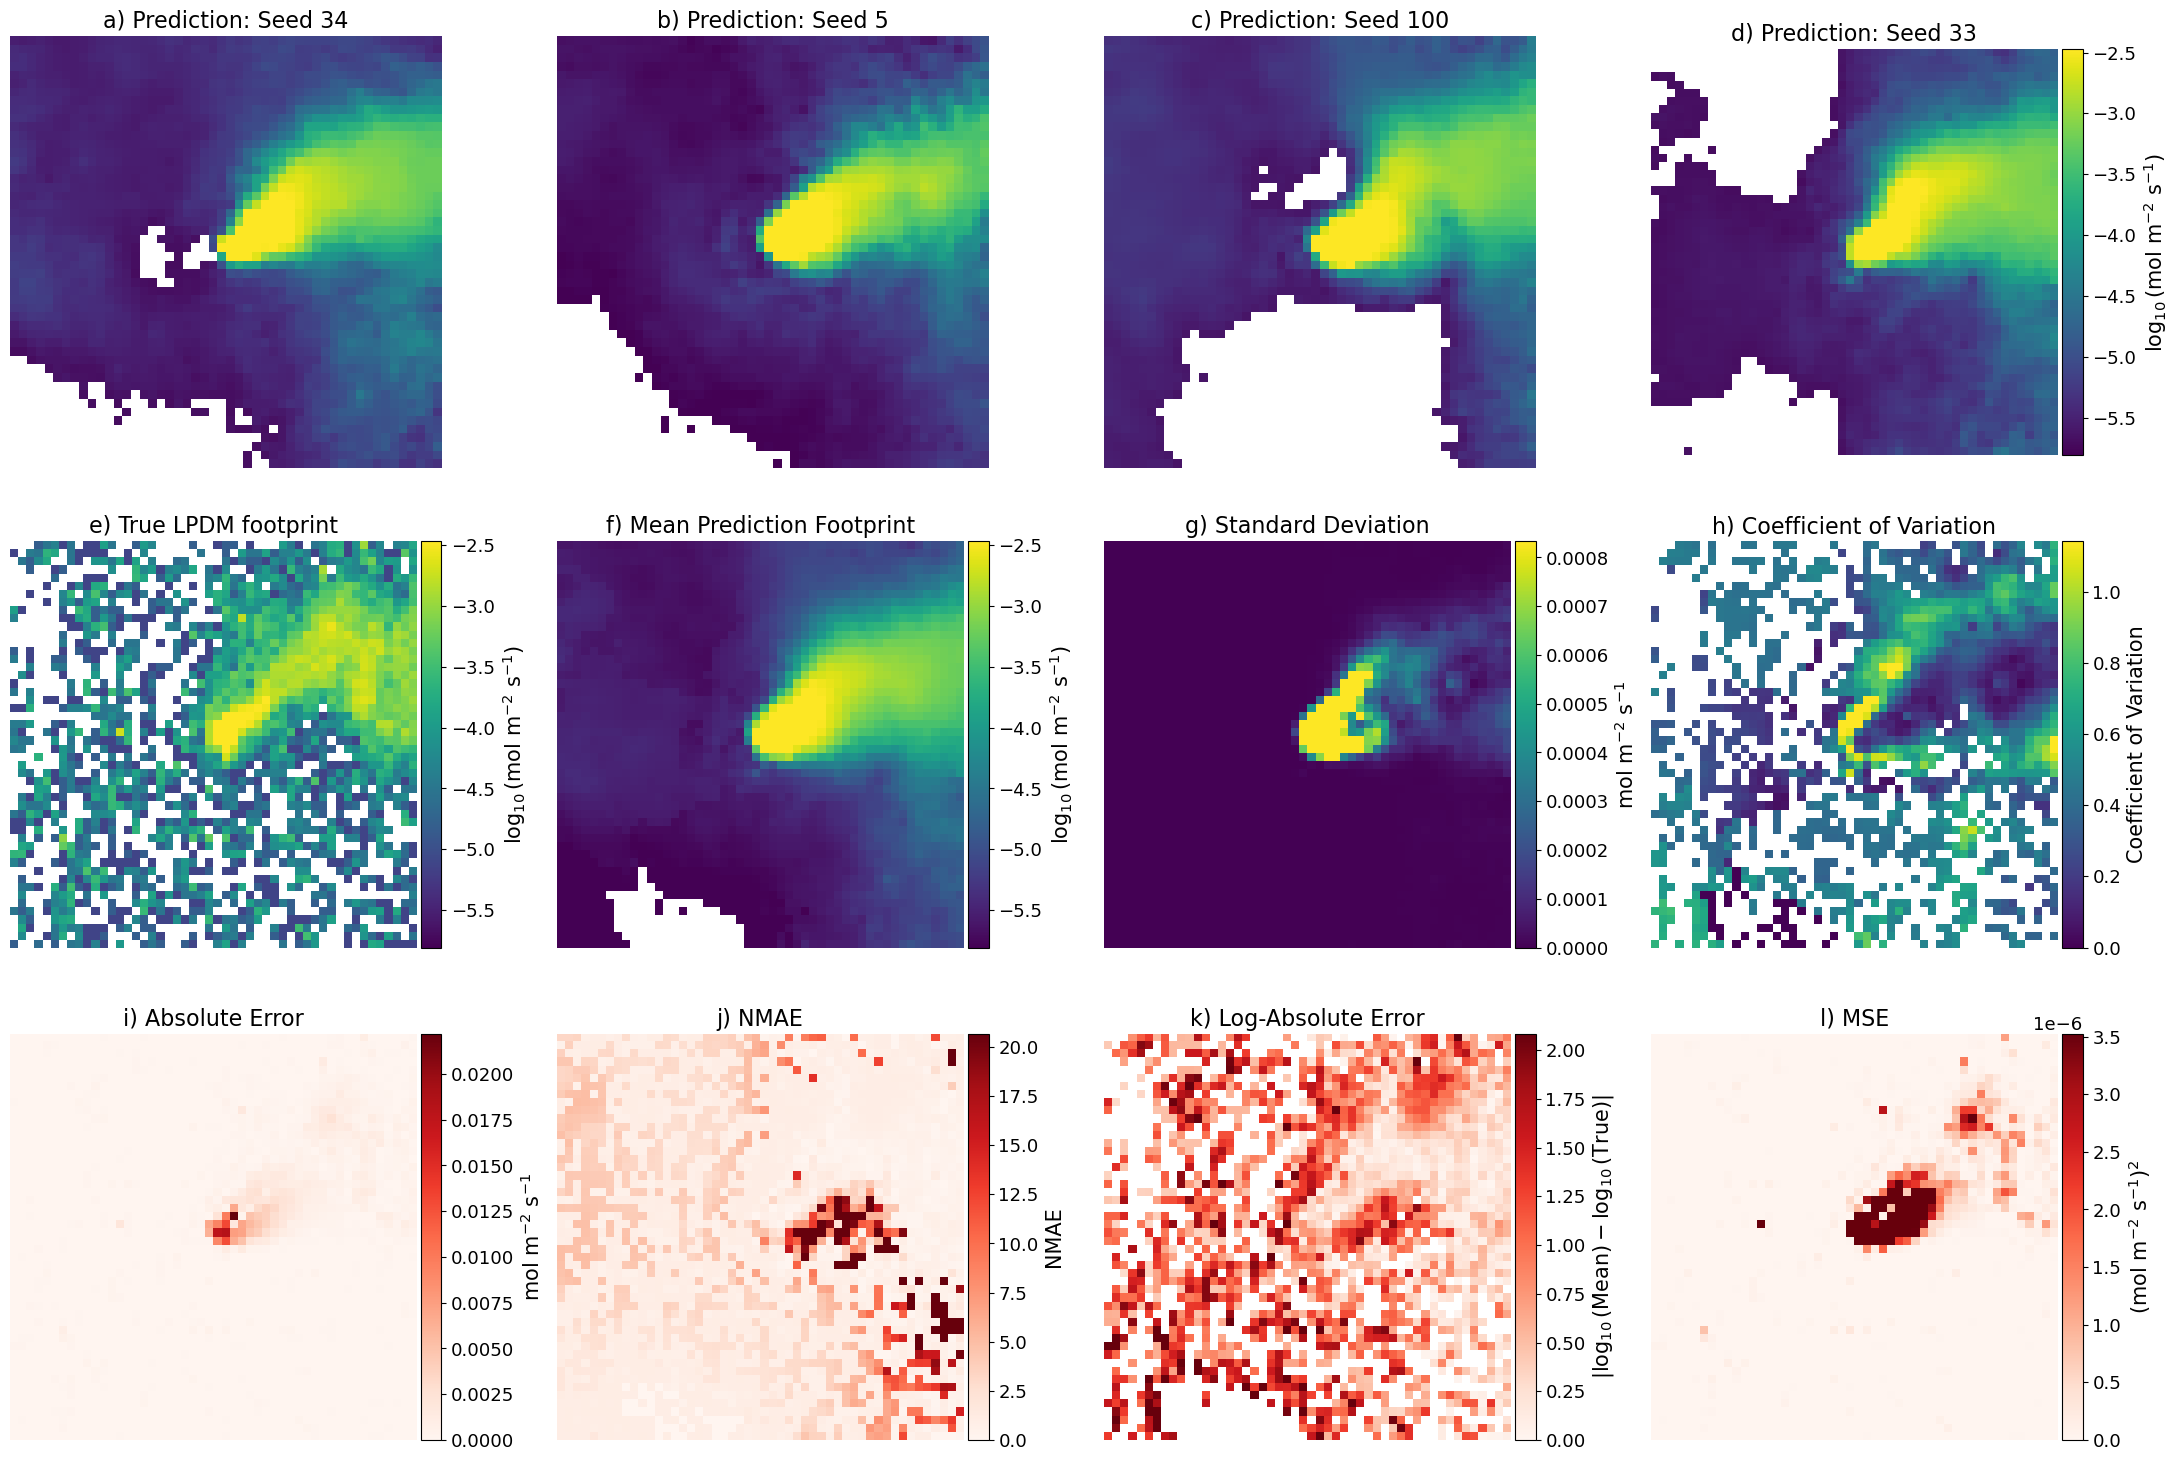

Saved uncertainty/summary_outputs/12panel_idx190_2016-04-15T16-37-35_with_stddev.pdf


In [17]:
# ------------------------- CONFIG -------------------------
time_idx = 190
epsilon  = 1e-6  # small stabiliser for CV

# Bigger fonts globally
plt.rcParams.update({
    "font.size": 15,         # base font size
    "axes.titlesize": 16,    # subplot titles
    "axes.labelsize": 15,    # axis labels (for colorbars etc.)
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 14,
    "figure.titlesize": 18
})

# --------------------- LOAD MODELS ------------------------
models = []
for name in model_names:
    mod = ModelEv(
        name,
        size=50,
        validation_set="0[1-3]",
        test_set="*",
        val_year="2016",
        test_year="2016",
        check_validation_overlap=True,
        path_to_files="/group/chemistry/acrg/ef17148/trained_satellite_models/",
    )
    mod.get_adjusted_models(which="thr_only")
    models.append((name, mod))

# Sanity check
n_times = [int(m.preds_test.thr.sizes["time"]) for _, m in models]
if any(time_idx >= nt for nt in n_times):
    raise IndexError(f"time_idx={time_idx} out of range; model time lengths: {n_times}")

# Reference time (for filenames)
ref_time = np.asarray(models[0][1].preds_test.time)[time_idx]
tstr = np.datetime64(ref_time).astype("datetime64[s]").astype(str)

# ---------------- SLICE & ENSEMBLE STATS ------------------
pred_native, pred_log = [], []
for _, mod in models:
    arr = np.asarray(mod.preds_test.thr.isel(time=time_idx))  # (lat, lon) native units
    pred_native.append(arr)
    pred_log.append(np.where(arr > 0, np.log10(arr), np.nan))

true_fp_native = np.asarray(models[0][1].preds_test.fp.isel(time=time_idx))
true_fp_log    = np.where(true_fp_native > 0, np.log10(true_fp_native), np.nan)

stack = np.stack(pred_native, axis=0)               # (seed, lat, lon)
mean_native = stack.mean(axis=0)
mean_log    = np.where(mean_native > 0, np.log10(mean_native), np.nan)
std_native  = stack.std(axis=0)
cv_native   = np.where(np.isfinite(mean_native), std_native / (mean_native + epsilon), np.nan)

# Mask CV in very low-signal truth & clip extremes (for display only)
pos_truth = true_fp_native[true_fp_native > 0]
thr = (np.nanpercentile(pos_truth, 20) if pos_truth.size else 0.0)
cv_masked = np.where(true_fp_native < thr, np.nan, cv_native)
cv_clip = np.nanpercentile(cv_masked, 99)
cv_show = np.clip(cv_masked, 0, cv_clip)

# SD clip (keeps colourbar useful)
std_vmax = np.nanpercentile(std_native, 98)

# ----------------------- ERRORS ---------------------------
abs_err = np.abs(mean_native - true_fp_native)               # same units as native
# NMAE (dimensionless) with robust stabiliser τ
tau = (np.nanpercentile(pos_truth, 5) * 0.1) if pos_truth.size else 1e-12
nmae = np.abs(mean_native - true_fp_native) / (true_fp_native + tau)
nmae_vmax = np.nanpercentile(nmae, 98)

# MSE (squared units)
mse = (mean_native - true_fp_native) ** 2
mse_vmax = np.nanpercentile(mse, 98)

# Log-absolute error (dimensionless)
with np.errstate(divide='ignore', invalid='ignore'):
    log_abs_err = np.abs(np.log10(mean_native) - np.log10(true_fp_native))
log_abs_err[~np.isfinite(log_abs_err)] = np.nan
lae_vmax = np.nanpercentile(log_abs_err, 98)

# -------- Shared colour scale for all log-panels ---------
stacked_log_for_scale = np.concatenate(
    [p[np.isfinite(p)].ravel() for p in pred_log if np.isfinite(p).any()] +
    [mean_log[np.isfinite(mean_log)].ravel()]
) if any(np.isfinite(p).any() for p in pred_log) and np.isfinite(mean_log).any() else np.array([0, 1])
log_vmin, log_vmax = np.nanpercentile(stacked_log_for_scale, [2, 98])

# ------------------------ PLOTTING ------------------------
from mpl_toolkits.axes_grid1 import make_axes_locatable
fig, axes = plt.subplots(3, 4, figsize=(22, 15))

def _transparent_cmap(base="viridis"):
    cmap = plt.cm.get_cmap(base).copy()
    cmap.set_bad(alpha=0.0)
    return cmap

cmap_log = _transparent_cmap("viridis")
cmap_cv  = _transparent_cmap("viridis")
cmap_abs = _transparent_cmap("Reds")

def add_cbar(ax, im, label):
    div = make_axes_locatable(ax)
    cax = div.append_axes("right", size="5%", pad=0.05)
    cb = fig.colorbar(im, cax=cax)
    cb.set_label(label)
    return cb

# ---- Row 1: Four predictions (log10) with shared colourbar ----
last_im = None
panel_letters = ['a', 'b', 'c', 'd']
for i, arr_log in enumerate(pred_log):
    ax = axes[0, i]
    last_im = ax.imshow(arr_log, vmin=log_vmin, vmax=log_vmax, origin="lower", cmap=cmap_log)
    title_txt = models_to_plot[i]['name'] if i < len(models_to_plot) else model_names[i]
    ax.set_title(f"{panel_letters[i]}) Prediction: {title_txt}")
    ax.axis("off")

# Shared colourbar at far right of the row
div_top = make_axes_locatable(axes[0, -1])
cax_top = div_top.append_axes("right", size="5%", pad=0.05)
cb_top = fig.colorbar(last_im, cax=cax_top)
cb_top.set_label(r'$\log_{10}(\mathrm{mol\ m^{-2}\ s^{-1}})$')

# ---- Row 2: True (log10), Mean (log10), Std Dev, CV ----
# (e) True footprint (log10)
ax_tf = axes[1, 0]
im_tf = ax_tf.imshow(true_fp_log, vmin=log_vmin, vmax=log_vmax, origin="lower", cmap=cmap_log)
ax_tf.set_title("e) True LPDM footprint"); ax_tf.axis("off")
add_cbar(ax_tf, im_tf, r'$\log_{10}(\mathrm{mol\ m^{-2}\ s^{-1}})$')

# (f) Mean prediction (log10)
ax_mean = axes[1, 1]
im_mean = ax_mean.imshow(mean_log, vmin=log_vmin, vmax=log_vmax, origin="lower", cmap=cmap_log)
ax_mean.set_title("f) Mean Prediction Footprint"); ax_mean.axis("off")
add_cbar(ax_mean, im_mean, r'$\log_{10}(\mathrm{mol\ m^{-2}\ s^{-1}})$')

# (g) Standard deviation (native units)
ax_std = axes[1, 2]
im_std = ax_std.imshow(np.clip(std_native, 0, std_vmax), origin="lower", cmap=cmap_cv, vmin=0, vmax=std_vmax)
ax_std.set_title("g) Standard Deviation"); ax_std.axis("off")
add_cbar(ax_std, im_std, r'$\mathrm{mol\ m^{-2}\ s^{-1}}$')

# (h) Coefficient of variation (dimensionless)
ax_cv = axes[1, 3]
im_cv = ax_cv.imshow(cv_show, origin="lower", cmap=cmap_cv)
ax_cv.set_title("h) Coefficient of Variation"); ax_cv.axis("off")
add_cbar(ax_cv, im_cv, "Coefficient of Variation")

# ---- Row 3: Absolute Error, NMAE, Log-Abs Error, MSE ----
# (i) Absolute error (native units)
ax_abs = axes[2, 0]
im_abs = ax_abs.imshow(abs_err, origin="lower", cmap=cmap_abs)
ax_abs.set_title("i) Absolute Error"); ax_abs.axis("off")
add_cbar(ax_abs, im_abs, r'$\mathrm{mol\ m^{-2}\ s^{-1}}$')

# (j) NMAE (dimensionless)
ax_nmae = axes[2, 1]
im_nmae = ax_nmae.imshow(nmae, origin="lower", cmap=cmap_abs, vmin=0, vmax=nmae_vmax)
ax_nmae.set_title("j) NMAE"); ax_nmae.axis("off")
add_cbar(ax_nmae, im_nmae, "NMAE")

# (k) Log-absolute error (dimensionless)
ax_lae = axes[2, 2]
im_lae = ax_lae.imshow(log_abs_err, origin="lower", cmap=cmap_abs, vmin=0, vmax=lae_vmax)
ax_lae.set_title("k) Log-Absolute Error"); ax_lae.axis("off")
add_cbar(ax_lae, im_lae, r'$|\log_{10}(\mathrm{Mean}) - \log_{10}(\mathrm{True})|$')

# (l) MSE (squared units)
ax_mse = axes[2, 3]
im_mse = ax_mse.imshow(mse, origin="lower", cmap=cmap_abs, vmin=0, vmax=mse_vmax)
ax_mse.set_title("l) MSE"); ax_mse.axis("off")
add_cbar(ax_mse, im_mse, r'$\mathrm{(mol\ m^{-2}\ s^{-1})^2}$')

# Make all panels square
for ax in axes.ravel():
    ax.set_aspect("equal")

plt.tight_layout()
out_pdf = save_path(f"12panel_idx{time_idx}_{tstr.replace(':','-')}_with_stddev.pdf")
plt.savefig(out_pdf, bbox_inches="tight")
plt.show()
plt.close()
print(f"Saved {out_pdf}")


## Wind rose figure

Found files: ['/group/chemistry/acrg/LPDM/fp_Elena/satellite_emulated_logv4/NAME_fps_intersect_square/SOUTHAMERICA/GOSAT-BRAZIL-column_SOUTHAMERICA_201604.nc', '/group/chemistry/acrg/LPDM/fp_Elena/satellite_emulated_logv4/NAME_fps_intersect_square/SOUTHAMERICA/GOSAT-BRAZIL-column_SOUTHAMERICA_201605.nc', '/group/chemistry/acrg/LPDM/fp_Elena/satellite_emulated_logv4/NAME_fps_intersect_square/SOUTHAMERICA/GOSAT-BRAZIL-column_SOUTHAMERICA_201606.nc', '/group/chemistry/acrg/LPDM/fp_Elena/satellite_emulated_logv4/NAME_fps_intersect_square/SOUTHAMERICA/GOSAT-BRAZIL-column_SOUTHAMERICA_201607.nc', '/group/chemistry/acrg/LPDM/fp_Elena/satellite_emulated_logv4/NAME_fps_intersect_square/SOUTHAMERICA/GOSAT-BRAZIL-column_SOUTHAMERICA_201608.nc', '/group/chemistry/acrg/LPDM/fp_Elena/satellite_emulated_logv4/NAME_fps_intersect_square/SOUTHAMERICA/GOSAT-BRAZIL-column_SOUTHAMERICA_201609.nc', '/group/chemistry/acrg/LPDM/fp_Elena/satellite_emulated_logv4/NAME_fps_intersect_square/SOUTHAMERICA/GOSAT-BRA

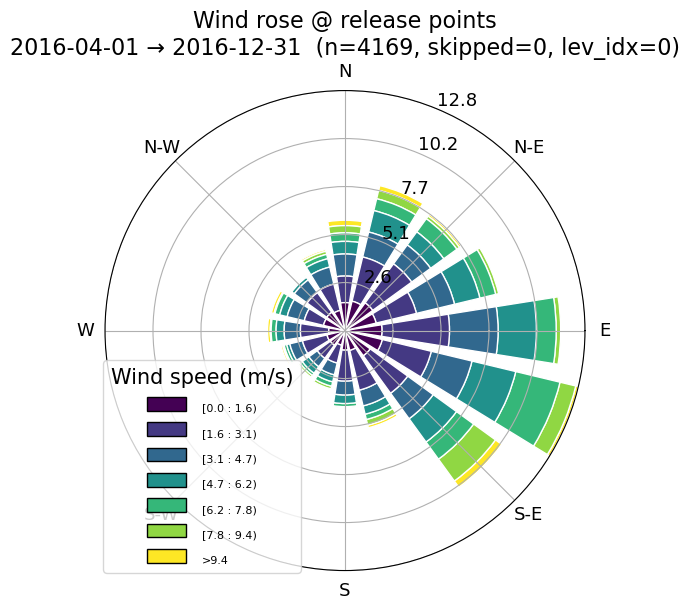

Saved uncertainty/summary_outputs/windrose_release_points.png


In [18]:
# Grab actual fp
year = "2016"
months = range(4, 13)  # April (4) through December (12)

file_list = []
for m in months:
    pattern = f"/group/chemistry/acrg/LPDM/fp_Elena/satellite_emulated_logv4/NAME_fps_intersect_square/SOUTHAMERICA/GOSAT-BRAZIL-column_SOUTHAMERICA_{year}{m:02d}.nc"
    file_list.extend(glob.glob(pattern))

print("Found files:", file_list)

real = xr.open_mfdataset(file_list, combine="by_coords")



# Load met data
met_data = xr.open_mfdataset(
    glob.glob("/group/chemistry/acrg/met_archive/UM/SOUTHAMERICA/*20160[4-9].nc")
    + glob.glob("/group/chemistry/acrg/met_archive/UM/SOUTHAMERICA/*20161[0-2].nc"),
    combine="by_coords"
)


# ================= Average CV map + Windrose at release points ================

# --- 0) Inputs you already have / assumptions --------------------------------
# cv_pred: xarray.DataArray with dims ("time","lat","lon") – coefficient of variation per seed ensemble
# std_pred/mean_pred exist already if you prefer to recompute cv_pred = std_pred/(mean_pred+eps)
# real: LPDM dataset with release locations for each footprint time (see your code below)
# met_data: meteorology dataset with coords ["time","latitude","longitude","model_level_number"]

# If cv_pred is not already defined, compute it quickly from summary_ds:
# epsilon = 1e-6
# cv_pred = summary_ds["std_deviation"] / (summary_ds["mean_prediction"] + epsilon)

# If 'real' or 'met_data' are not loaded yet, uncomment and adjust:
# import glob, xarray as xr
# year, month = "2016", "*"
# real = xr.open_mfdataset(glob.glob(f"/group/chemistry/acrg/LPDM/fp_Elena/satellite_emulated_logv4/NAME_fps_intersect_square/SOUTHAMERICA/GOSAT-BRAZIL-column_SOUTHAMERICA_{year}{month}.nc"))
# met_data = xr.open_mfdataset(
#     glob.glob("/group/chemistry/acrg/met_archive/UM/SOUTHAMERICA/*20160[4-9].nc")
#     + glob.glob("/group/chemistry/acrg/met_archive/UM/SOUTHAMERICA/*20161[0-2].nc"),
#     combine="by_coords"
# )

# --- 1) Average CV over test set ----------------------------------------------
cv_mean_time = cv_pred.mean(dim="time")   # spatial average across the test set


# ---------- Wind rose @ release points across the test set (robust v3: index-based) ----------
from windrose import WindroseAxes

# 1) Overlap time between real and cv_pred (or any test-time coord you trust)
common_time = np.intersect1d(real.time.values, cv_pred.time.values)
if common_time.size == 0:
    raise ValueError("No overlapping times between 'real' and 'cv_pred'.")

real_aligned = real.sel(time=common_time)
rel_lats = real_aligned.release_lat.values.astype(float)
rel_lons = real_aligned.release_lon.values.astype(float)
times    = real_aligned.time.values

# 2) Coordinate names (adjust if yours differ)
LAT_NAME, LON_NAME, LEV_NAME = "latitude", "longitude", "model_level_number"

# 3) Extract raw coord arrays (numpy) and pick a lowest level index safely
lat_vals  = np.asarray(met_data[LAT_NAME].values)
lon_vals  = np.asarray(met_data[LON_NAME].values)
time_vals = np.asarray(met_data.time.values)
lev_vals  = np.asarray(met_data[LEV_NAME].values)

# Use level 0 by default (most UM/ERA products order ground->aloft); or compute from level_height if you have it
if "level_height" in met_data:
    # find globally-lowest level using a reduction; compute to drop dask
    other_dims = tuple(d for d in met_data.level_height.dims if d != LEV_NAME)
    lvl_mean = met_data.level_height.mean(dim=other_dims, skipna=True)
    low_lev_val = lvl_mean.idxmin(LEV_NAME).compute().item()
    # translate value to index
    lev_idx = int(np.argmin(np.abs(lev_vals - low_lev_val)))
else:
    lev_idx = 0  # fallback: first level as "lowest"

# 4) Nearest-index helper (no reindexing)
def nearest_idx(arr, val):
    # works for datetime64 and floats alike
    return int(np.nanargmin(np.abs(arr - val)))

# Tolerances (skip sample if too far from any gridpoint)
lat_tol_deg = 1.0     # degrees
lon_tol_deg = 1.0     # degrees
time_tol_hr = 6       # hours

def within_tol(idx_lat, idx_lon, idx_time, lat, lon, t):
    dlat = np.abs(lat_vals[idx_lat] - lat)
    dlon = np.abs(lon_vals[idx_lon] - lon)
    dt   = np.abs((time_vals[idx_time] - np.datetime64(t)).astype('timedelta64[h]').astype(int))
    return (dlat <= lat_tol_deg) and (dlon <= lon_tol_deg) and (dt <= time_tol_hr)

# 5) Sample u/v at each release point/time using .isel and get scalars robustly
u_vals, v_vals = [], []
n_total, n_skip = len(times), 0

for t, la, lo in zip(times, rel_lats, rel_lons):
    try:
        i_lat  = nearest_idx(lat_vals, la)
        i_lon  = nearest_idx(lon_vals, lo)
        i_time = nearest_idx(time_vals, np.datetime64(t))

        if not within_tol(i_lat, i_lon, i_time, la, lo, t):
            n_skip += 1
            continue

        u_da = met_data.x_wind.isel({LEV_NAME: lev_idx, "time": i_time, LAT_NAME: i_lat, LON_NAME: i_lon})
        v_da = met_data.y_wind.isel({LEV_NAME: lev_idx, "time": i_time, LAT_NAME: i_lat, LON_NAME: i_lon})

        # robust scalar extraction for dask-backed arrays
        u_val = float(u_da.to_numpy().item())
        v_val = float(v_da.to_numpy().item())

        if np.isfinite(u_val) and np.isfinite(v_val):
            u_vals.append(u_val); v_vals.append(v_val)
        else:
            n_skip += 1
    except Exception:
        n_skip += 1

u_arr = np.asarray(u_vals, dtype=float)
v_arr = np.asarray(v_vals, dtype=float)

if u_arr.size == 0:
    print(f"[windrose] No valid met samples (total={n_total}, skipped={n_skip}). "
          f"Try relaxing tolerances or checking coord names.")
else:
    ws = np.hypot(u_arr, v_arr)
    wd_from = (np.degrees(np.arctan2(-u_arr, -v_arr)) + 360) % 360

    # Data-driven bins starting at 0
    w98 = float(np.nanpercentile(ws, 98))
    wmx = float(np.nanmax(ws))
    hi  = max(1.0, min(max(w98, 1.0), max(wmx, 1.0)))
    sp_bins = np.linspace(0.0, hi, 7)

    fig_wr = plt.figure(figsize=(6, 6))
    ax_wr = WindroseAxes.from_ax(fig=fig_wr)
    if hi <= 1e-6:
        ax_wr.bar(wd_from, ws, bins=[0.1], opening=0.8, edgecolor="white",
                  calm_limit=0.05, normed=True)
    else:
        ax_wr.bar(wd_from, ws, bins=sp_bins, opening=0.8, edgecolor="white", normed=True)

    ax_wr.set_legend(title="Wind speed (m/s)")
    start = np.datetime_as_string(common_time.min(), unit="D")
    end   = np.datetime_as_string(common_time.max(), unit="D")
    ax_wr.set_title(f"Wind rose @ release points\n{start} → {end}  (n={u_arr.size}, skipped={n_skip}, lev_idx={lev_idx})")

    out_wr = save_path("windrose_release_points.png")
    plt.savefig(out_wr, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Saved {out_wr}")


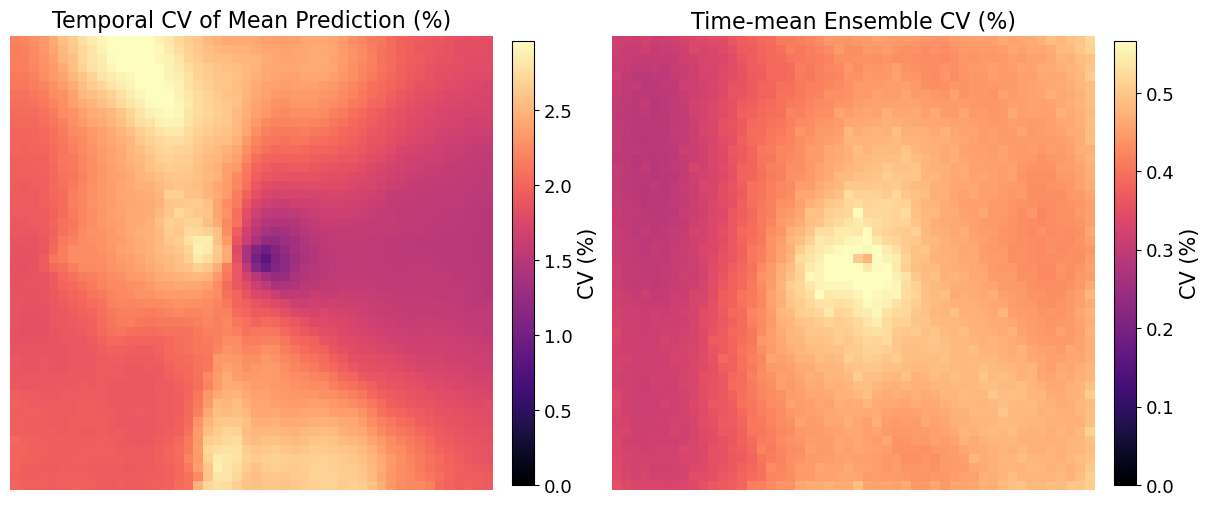

In [22]:
# 1) Temporal CV of mean prediction
cv_temporal = (mean_pred.std("time") / (mean_pred.mean("time") + epsilon))

# 2) Time-mean ensemble CV
cv_ens_time_mean = ((std_pred / (mean_pred + epsilon)).mean("time"))

# Use percentile clipping for nicer colorbars
vmax1 = float(np.nanpercentile(cv_temporal, 99))
vmax2 = float(np.nanpercentile(cv_ens_time_mean, 99))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

p1 = cv_temporal.plot(ax=axes[0], cmap="magma", vmin=0, vmax=vmax1, add_colorbar=False)
axes[0].set_title("Temporal CV of Mean Prediction (%)")
axes[0].axis("off")
cb1 = plt.colorbar(p1, ax=axes[0], fraction=0.046, pad=0.04)
cb1.set_label("CV (%)")

p2 = cv_ens_time_mean.plot(ax=axes[1], cmap="magma", vmin=0, vmax=vmax2, add_colorbar=False)
axes[1].set_title("Time-mean Ensemble CV (%)")
axes[1].axis("off")
cb2 = plt.colorbar(p2, ax=axes[1], fraction=0.046, pad=0.04)
cb2.set_label("CV (%)")

plt.savefig(save_path("cv_temporal_and_ensemble_mean.png"), dpi=200, bbox_inches="tight")
plt.show()
plt.close()


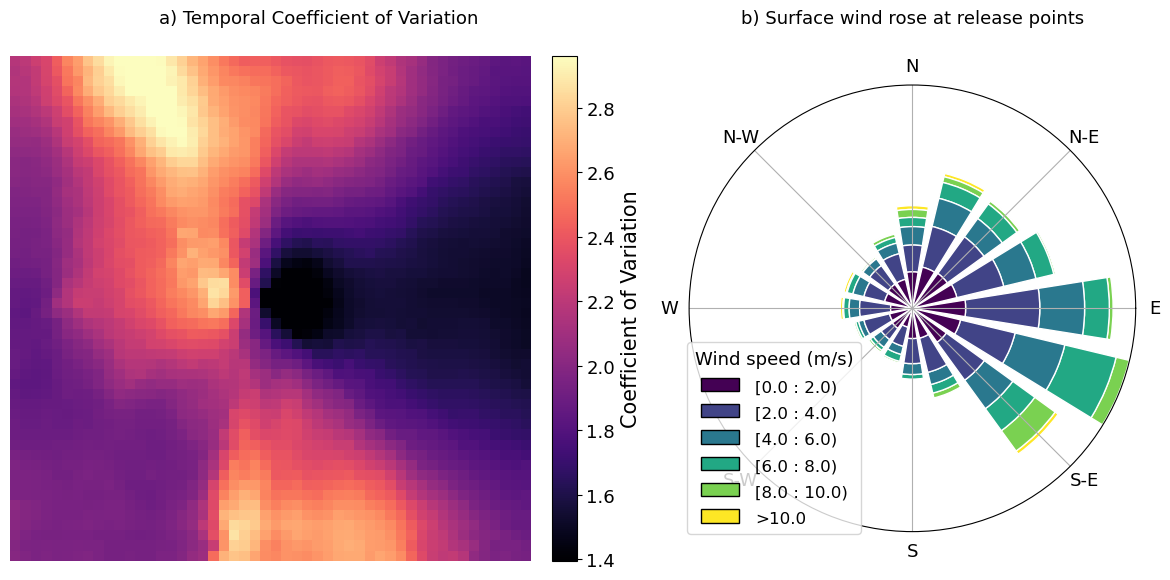

Saved uncertainty/summary_outputs/13_temporal_cv_and_windrose_tight.pdf


In [23]:
from matplotlib.gridspec import GridSpec

# nice round speed bins
speed_bins = np.arange(0, 12, 2)
vmin = float(np.nanpercentile(cv_temporal, 1))
vmax = float(np.nanpercentile(cv_temporal, 99))

# Figure with a slim colorbar column and small gaps
fig = plt.figure(figsize=(13.5, 5.8))
gs  = GridSpec(
    nrows=1, ncols=3, figure=fig,
    width_ratios=[0.75, 0.035, 1],
)

# Left: CV map
ax_map = fig.add_subplot(gs[0, 0])
p = cv_temporal.plot(ax=ax_map, cmap="magma", vmin=vmin, vmax=vmax, add_colorbar=False)
ax_map.axis("off")

# Colorbar in its own (very slim) cell
cax = fig.add_subplot(gs[0, 1])
cb  = fig.colorbar(p, cax=cax)
cb.set_label("Coefficient of Variation")

# Right: wind rose placed exactly in the right-hand grid cell
rect = gs[0, 2].get_position(fig)
ax_wr = WindroseAxes(fig, rect)
fig.add_axes(ax_wr)

bars = ax_wr.bar(wd_from, ws, bins=speed_bins, opening=0.8,
                 edgecolor="white", normed=True)

# Legend with larger font
leg = ax_wr.set_legend(title="Wind speed (m/s)")
plt.setp(leg.get_texts(), fontsize=12)
plt.setp(leg.get_title(), fontsize=13)

ax_wr.set_yticks([]); ax_wr.set_yticklabels([])

# --- Force titles to same height and center them over their panels ---
title_y = 0.98  # figure y for both titles (same vertical line)

# centers of the left CV panel and right wind-rose panel in figure coords
bbox_left  = gs[0, 0].get_position(fig)   # Bbox(x0,y0,x1,y1)
bbox_right = gs[0, 2].get_position(fig)

xc_left  = 0.5 * (bbox_left.x0  + bbox_left.x1)
xc_right = 0.5 * (bbox_right.x0 + bbox_right.x1)

# place titles centered over each panel
fig.text(xc_left,  title_y, "a) Temporal Coefficient of Variation",
         ha="center", va="bottom", fontsize=13)
fig.text(xc_right, title_y, "b) Surface wind rose at release points",
         ha="center", va="bottom", fontsize=13)


# Trim outer margins & inter-panel spacing
fig.subplots_adjust(left=0.04, right=0.99, top=0.93, bottom=0.06, wspace=0.05)

out = save_path("13_temporal_cv_and_windrose_tight.pdf")
plt.savefig(out, bbox_inches="tight")
plt.show()
plt.close()
print(f"Saved {out}")


## Older plots

loading data from /group/chemistry/acrg/ef17148/trained_satellite_models/satellite_clever2_50_[[]6,12[]]_vB_logv3_weightedbytruth_B/predictions/preds_2016*.nc
using validation data: 20160[1-3] and test data: 2016*. Checking overlap between the two: True


/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 311 times more chunks
  return self.array[key]


loading data from /group/chemistry/acrg/ef17148/trained_satellite_models/satellite_clever2_50_[[]6,12[]]_vB_logv3_weightedbytruth_assym_C_seed5/predictions/preds_2016*.nc
using validation data: 20160[1-3] and test data: 2016*. Checking overlap between the two: True


/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 311 times more chunks
  return self.array[key]


loading data from /group/chemistry/acrg/ef17148/trained_satellite_models/satellite_clever2_50_[[]6,12[]]_vB_logv3_weightedbytruth_assym_C_seed100/predictions/preds_2016*.nc
using validation data: 20160[1-3] and test data: 2016*. Checking overlap between the two: True


/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 311 times more chunks
  return self.array[key]


loading data from /group/chemistry/acrg/ef17148/trained_satellite_models/satellite_clever2_50_[[]6,12[]]_vB_logv3_weightedbytruth_assym_C_seed33/predictions/preds_2016*.nc
using validation data: 20160[1-3] and test data: 2016*. Checking overlap between the two: True


/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 311 times more chunks
  return self.array[key]


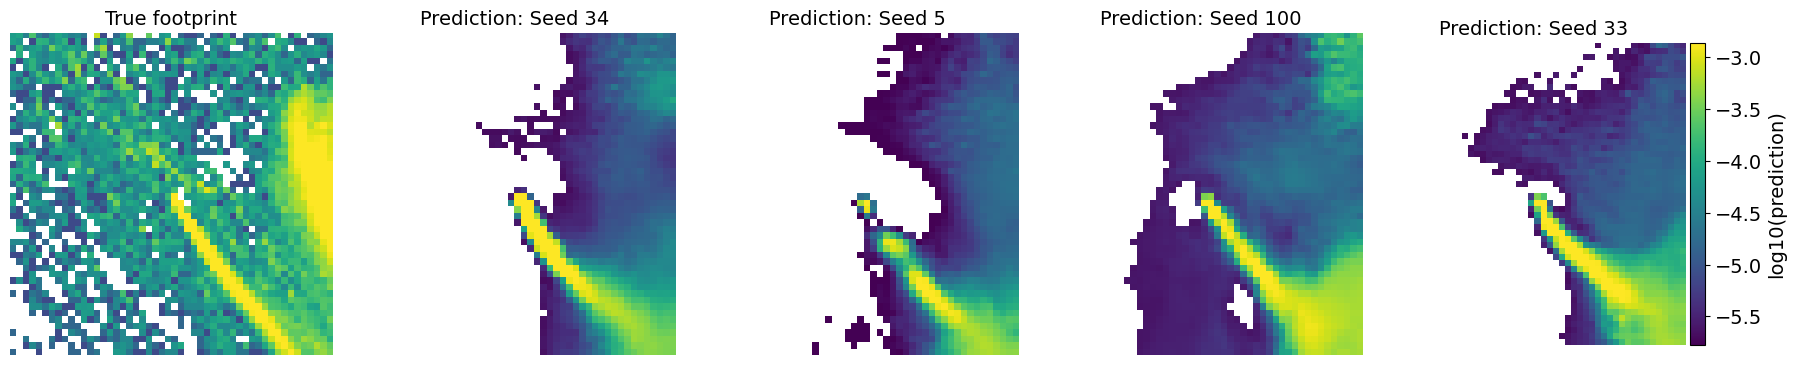

In [7]:
fig, axes = plt.subplots(1, len(model_names)+1, figsize=(4.5 * len(model_names), 4.5))

models = []
data_logs = []

# ---- Load once, compute robust global vmin/vmax across ALL models ----
for name in model_names:
    mod = ModelEv(
        name,
        size=50,
        validation_set="0[1-3]",
        test_set="*",
        val_year="2016",
        test_year="2016",
        check_validation_overlap=True,
        path_to_files="/group/chemistry/acrg/ef17148/trained_satellite_models/"
    )
    mod.get_adjusted_models(which="thr_only")

    if "time" in mod.preds_test.thr.dims:
        arr = np.asarray(mod.preds_test.thr.isel(time=single_time_step))

    # Avoid -inf from log10(0) or <=0 values by masking them out
    arr_log = np.where(arr > 0, np.log10(arr), np.nan)

    models.append((name, mod))
    data_logs.append(arr_log)


# robust limits (e.g., 2nd–98th percentile) over ALL models, ignoring NaNs
stacked = np.concatenate([d[np.isfinite(d)].ravel() for d in data_logs if np.isfinite(d).any()])
vmin = np.nanpercentile(stacked, 2)
vmax = np.nanpercentile(stacked, 98)

# ---- Plot ----
last_im = None

# first subplot: true footprint
ax0 = axes[0] if len(model_names) > 0 else axes
true_fp = np.log10(mod.preds_test.fp[single_time_step])
ax0.imshow(true_fp, vmin=vmin, vmax=vmax)
ax0.set_title("True footprint", wrap=False)
ax0.axis("off")

# Then plot the predictions for each model
for i, ((name, _), data_log) in enumerate(zip(models, data_logs), start=1):
    ax = axes[i]
    last_im = ax.imshow(data_log, vmin=vmin, vmax=vmax)
    ax.set_title("Prediction: " + models_to_plot[i-1]['name'], wrap=False)
    ax.axis("off")


divider = make_axes_locatable(axes[-1])
cax = divider.append_axes("right", size="5%", pad=0.05)
cb = fig.colorbar(last_im, cax=cax)
cb.set_label("log10(prediction)")

plt.tight_layout()
plt.savefig(save_path(f"10fp_predictions_all_models_one_timepoint{single_time_step}.png"),  bbox_inches = 'tight')
plt.savefig(save_path(f"10fp_predictions_all_models_one_timepoint{single_time_step}.pdf"),  bbox_inches = 'tight')
plt.show()
plt.close()

In [8]:
# Build a list of DataArrays and a matching list of seed names
thr_list = []
seed_names = []

for name, mod in models:
    thr_list.append(xr.DataArray(mod.preds_test.thr, dims=["time", "lat", "lon"]))
    seed_names.append(name)

# Concatenate along a new "seed" dimension, labelled by model names
thr_preds = xr.concat(
    thr_list,
    dim=xr.DataArray(seed_names, dims=["seed"], name="seed")
)

# Ground truth from the first model
fp = xr.DataArray(models[0][1].preds_test.fp, dims=["time", "lat", "lon"])

## Basic statistics

### Per timestep

In [9]:
save_file_summary = save_path("uncertainty_summary_statistics.nc")
if os.path.exists(save_file_summary):
    print(f"Loading cached stats arrays from {save_file_summary}...")
    # Reopen the dataset
    summary_ds = xr.open_dataset(save_file_summary)

    # Extract variables as NumPy arrays
    mean_pred = summary_ds["mean_prediction"]
    std_pred = summary_ds["std_deviation"]
    cv_pred = summary_ds["coefficient_of_variation"]
    p5 = summary_ds["percentile_5"]
    p95 = summary_ds["percentile_95"]
    range_90 = summary_ds["range_90"]
    disagreement_mask = summary_ds["disagreement_zone"]

else:
    mean_pred = thr_preds.mean(dim="seed")
    std_pred = thr_preds.std(dim="seed")
    cv_pred = std_pred / (mean_pred + epsilon)
    q_vals = thr_preds.quantile([0.05, 0.95], dim="seed")
    p5 = q_vals.sel(quantile=0.05).drop_vars("quantile")
    p95 = q_vals.sel(quantile=0.95).drop_vars("quantile")
    range_90 = p95 - p5

    # Prediction disagreement zone (binary mask)
    disagreement_mask = (range_90 > disagreement_threshold)

    # Save summary statistics to NetCDF
    summary_ds = xr.Dataset({
        "mean_prediction": mean_pred,
        "std_deviation": std_pred,
        "coefficient_of_variation": cv_pred,
        "percentile_5": p5,
        "percentile_95": p95,
        "range_90": range_90,
        "disagreement_zone": disagreement_mask.astype("int")
    })
    summary_ds.to_netcdf(save_file_summary)
    print("Saved uncertainty_summary_statistics.nc")

Loading cached stats arrays from uncertainty/summary_outputs/uncertainty_summary_statistics.nc...


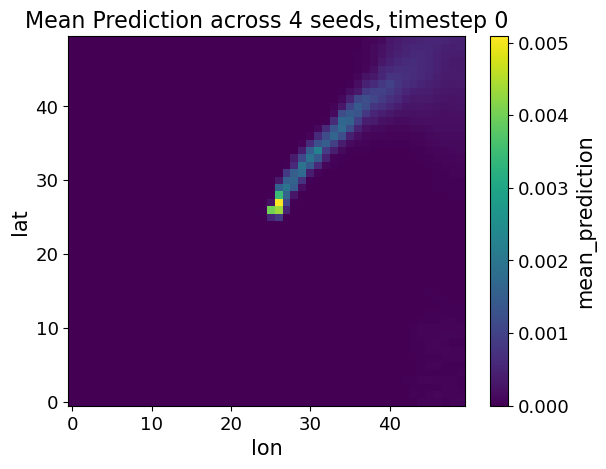

Saved Mean Prediction across 4 seeds, timestep 0.png


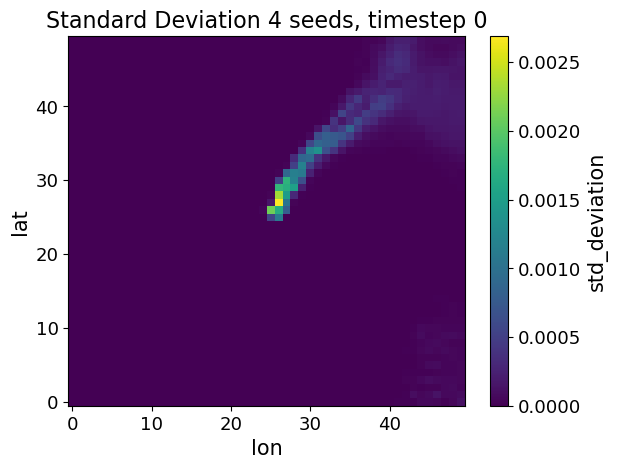

Saved Standard Deviation 4 seeds, timestep 0.png


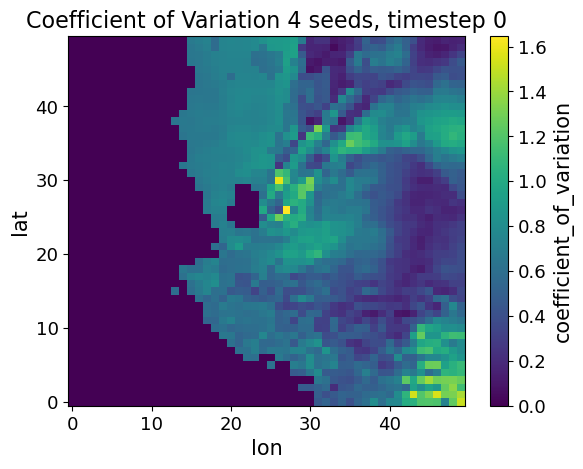

Saved Coefficient of Variation 4 seeds, timestep 0.png


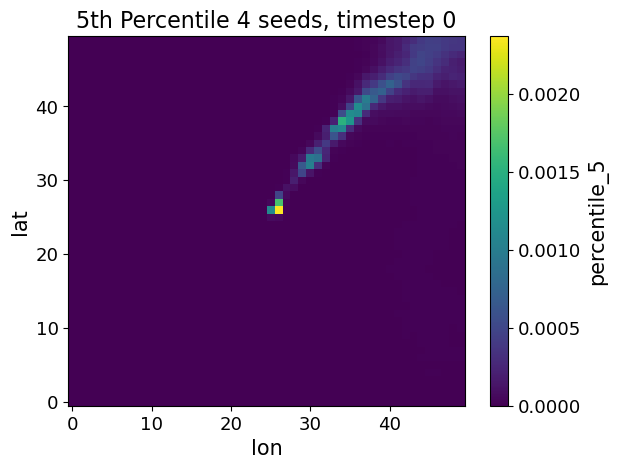

Saved 5th Percentile 4 seeds, timestep 0.png


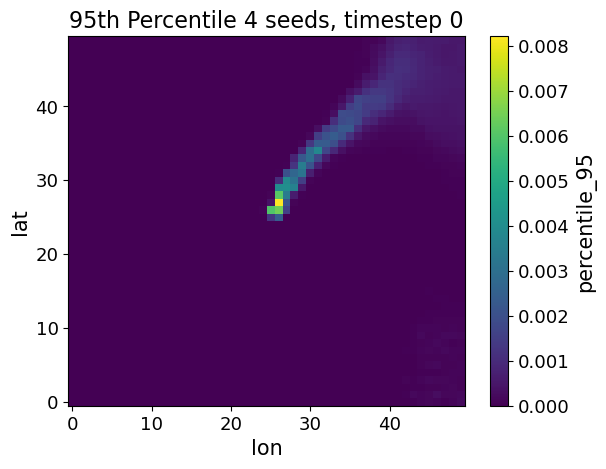

Saved 95th Percentile 4 seeds, timestep 0.png


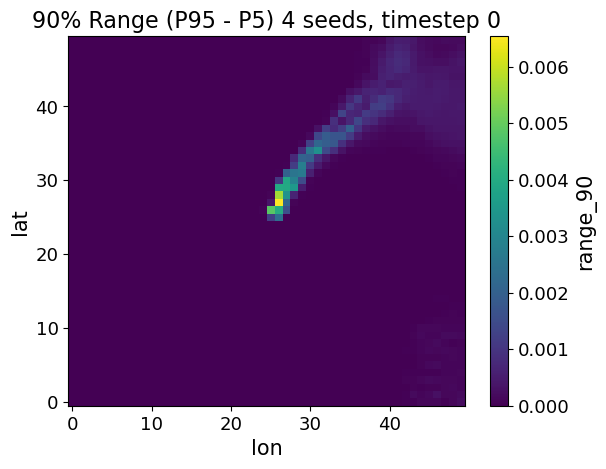

Saved 90% Range (P95 - P5) 4 seeds, timestep 0.png


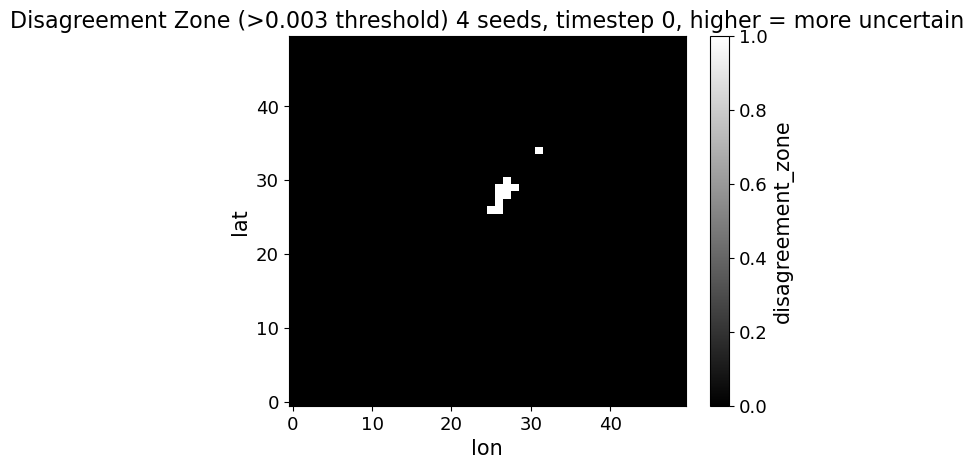

Saved Disagreement Zone (>0.003 threshold) 4 seeds, timestep 0, higher = more uncertain.png


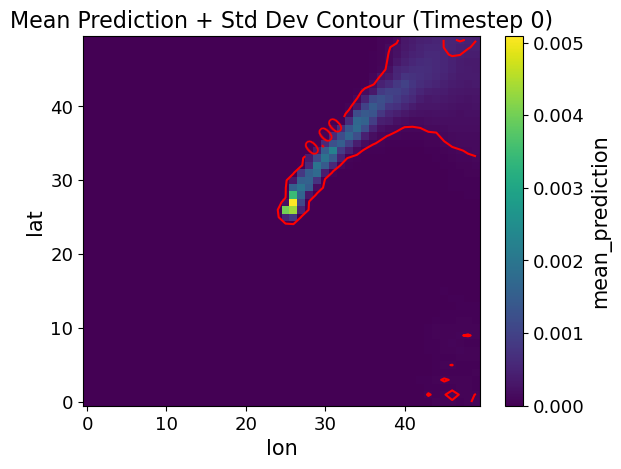

Saved mean_with_std_contour.png


In [26]:
num_models = len(models)

# Plot basic metrics
plots = {
    f"Mean Prediction across {num_models} seeds, timestep {single_time_step}": summary_ds["mean_prediction"],
    f"Standard Deviation {num_models} seeds, timestep {single_time_step}": summary_ds["std_deviation"],
    f"Coefficient of Variation {num_models} seeds, timestep {single_time_step}" : summary_ds["coefficient_of_variation"],
    f"5th Percentile {num_models} seeds, timestep {single_time_step}": summary_ds["percentile_5"],
    f"95th Percentile {num_models} seeds, timestep {single_time_step}": summary_ds["percentile_95"],
    f"90% Range (P95 - P5) {num_models} seeds, timestep {single_time_step}": summary_ds["range_90"],
    f"Disagreement Zone (>{disagreement_threshold} threshold) {num_models} seeds, timestep {single_time_step}, higher = more uncertain": disagreement_mask
}

for name, data in plots.items():
    plt.figure()
    if "time" in data.dims:
        data = data.isel(time=single_time_step)
    data.plot(cmap="viridis" if "Zone" not in name else "gray")
    plt.title(name)
    plt.savefig(save_path(name.replace(" ", "_").lower() + ".png"))
    plt.show()
    plt.close()
    print(f"Saved {name}.png")

# Uncertainty-weighted visualisation (mean + contour of standard deviation)
plt.figure()
mean_pred.isel(time=0).plot(cmap="viridis")  # reduce to 2D
cs = plt.contour(std_pred.isel(time=time_steps[0]), levels=[std_pred.mean().item()], colors="red")
plt.clabel(cs, fmt="%.2f", colors="red")
plt.title("Mean Prediction + Std Dev Contour (Timestep 0)")
plt.savefig(save_path("mean_with_std_contour.png"))
plt.show()
plt.close()
print("Saved mean_with_std_contour.png")



# Histograms showing distributions of uncertainty metrics
histograms = {
    "Standard Deviation": std_pred.values.flatten(),
    "Coefficient of Variation": cv_pred.values.flatten(),
    "90% Prediction Range": range_90.values.flatten()
}


#### --- Could rethreshold eg mean prediction?

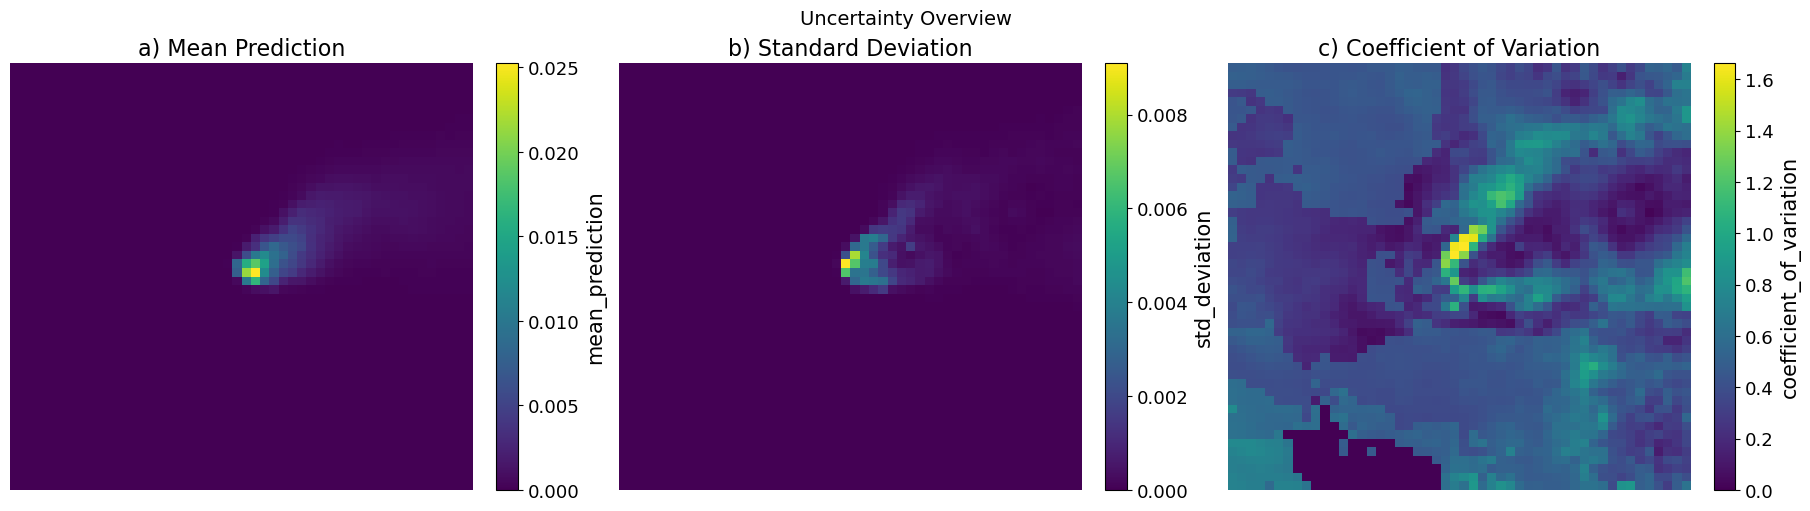

Saved 11uncertainty_subplots_t190.pdf


In [27]:
# Create subplots for mean, SD, and coefficient of variation
single_time_step = 190

def _slice_2d(da, t_idx):
    """Return a 2D slice (drops time if present)."""
    return da.isel(time=t_idx) if "time" in da.dims else da

# Pick out the three layers
mean_da = _slice_2d(summary_ds["mean_prediction"], single_time_step)
std_da  = _slice_2d(summary_ds["std_deviation"],  single_time_step)
cv_da   = _slice_2d(summary_ds["coefficient_of_variation"], single_time_step)

# (Optional) clean CV for nicer colour scaling
cv_da = cv_da.where(np.isfinite(cv_da))

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# Plot each metric on its own axes
p0 = mean_da.plot(ax=axes[0], cmap="viridis")
axes[0].set_title(f"a) Mean Prediction")

p1 = std_da.plot(ax=axes[1], cmap="viridis")
axes[1].set_title(f"b) Standard Deviation")

p2 = cv_da.plot(ax=axes[2], cmap="viridis")
axes[2].set_title(f"c) Coefficient of Variation")

axes[0].axis("off")
axes[1].axis("off")
axes[2].axis("off")

fig.suptitle("Uncertainty Overview", fontsize=14)
out_name = f"11uncertainty_subplots_t{single_time_step}.pdf"
plt.savefig(save_path(out_name), bbox_inches="tight")
plt.show()
plt.close()
print(f"Saved {out_name}")

### Compute errors

In [28]:
abs_error = abs(mean_pred - fp)

error_vs_uncertainty = xr.Dataset({
    "abs_error": abs_error,
    "std_deviation": std_pred
})
error_vs_uncertainty.to_netcdf(save_path("error_vs_uncertainty.nc"))
print("Saved error_vs_uncertainty.nc")
# Scatter correlation

err_flat = abs_error.values.flatten()
unc_flat = std_pred.values.flatten()

valid = ~np.isnan(err_flat) & ~np.isnan(unc_flat)
corr, pval = pearsonr(unc_flat[valid], err_flat[valid])
print(f"Pearson r between uncertainty and abs error: {corr:.3f} (p={pval:.2g})")


Saved error_vs_uncertainty.nc
Pearson r between uncertainty and abs error: 0.675 (p=0)


## Distributions

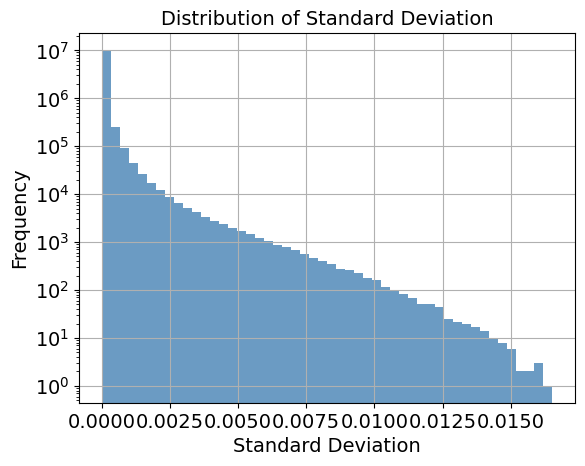

Saved hist_standard_deviation.png


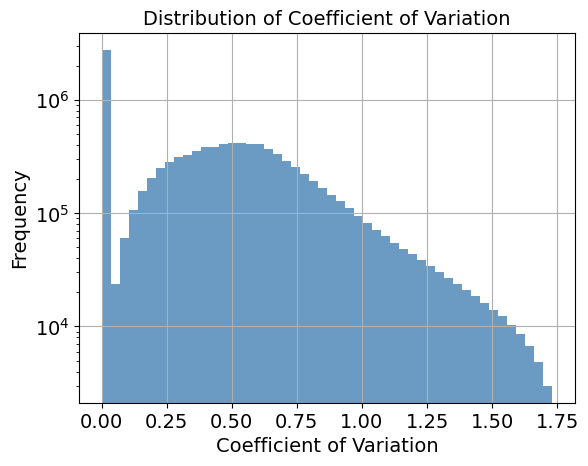

Saved hist_coefficient_of_variation.png


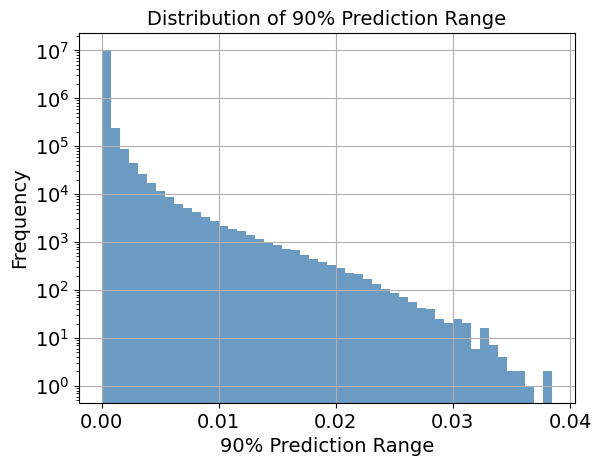

Saved hist_90%_prediction_range.png


In [11]:
# Histograms showing distributions of uncertainty metrics, aggregated over time
histograms = {
    "Standard Deviation": summary_ds["std_deviation"].values.flatten(),
    "Coefficient of Variation": summary_ds["coefficient_of_variation"].values.flatten(),
    "90% Prediction Range": summary_ds["range_90"].values.flatten()
}

for name, values in histograms.items():
    plt.figure()
    plt.hist(values, bins=50, color="steelblue", alpha=0.8)
    plt.yscale("log")
    plt.title(f"Distribution of {name}")
    plt.xlabel(name)
    plt.ylabel("Frequency")
    plt.grid(True)
    filename = f"hist_{name.lower().replace(' ', '_')}.png"
    plt.savefig(save_path(filename))
    plt.show()
    plt.close()
    print(f"Saved {filename}")

## Plots vs true fps

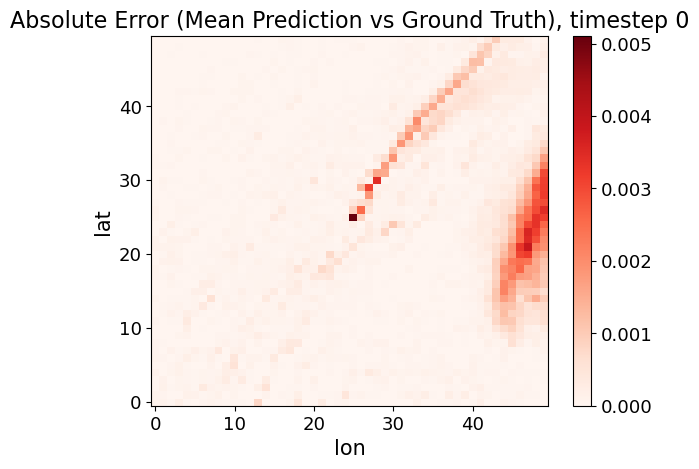

Saved abs_error.png


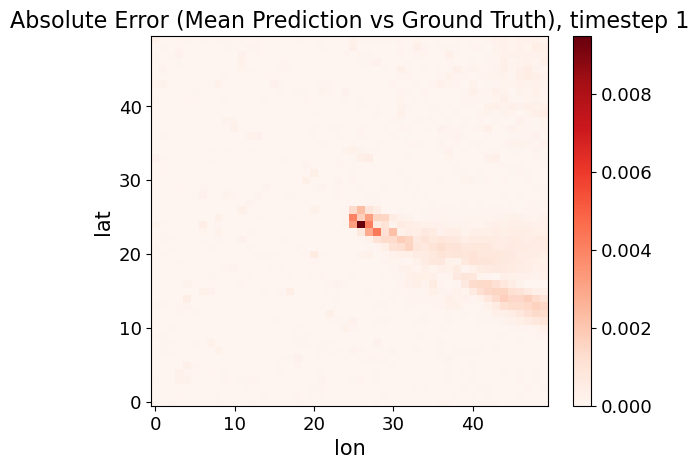

Saved abs_error.png


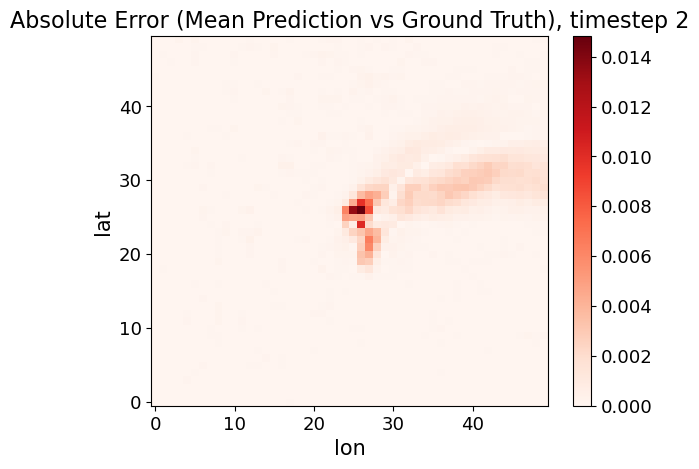

Saved abs_error.png


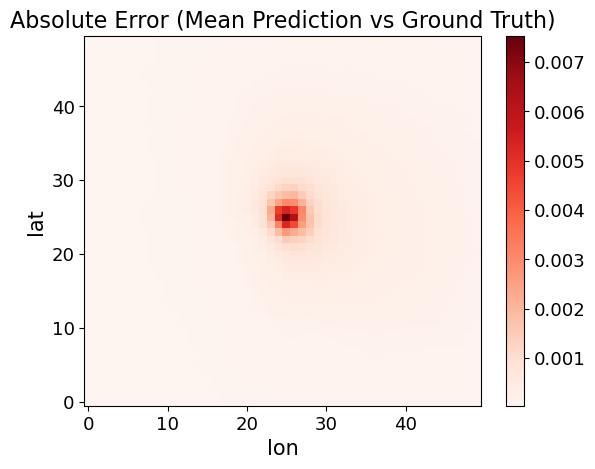

Saved abs_error.png


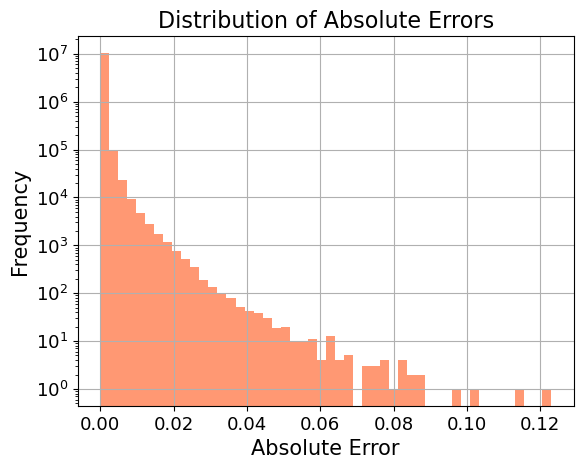

Saved hist_abs_error.png
Pearson correlation between uncertainty and error: 0.675 (p=0)


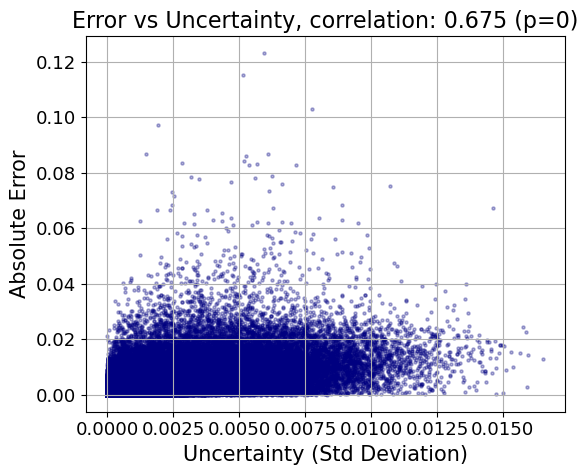

Saved scatter_error_vs_uncertainty.png


In [29]:
# Plot absolute error

for time_step in time_steps:
    plt.figure()
    abs_error.isel(time=time_step).plot.imshow(cmap="Reds")
    plt.title(f"Absolute Error (Mean Prediction vs Ground Truth), timestep {time_step}")
    plt.savefig(save_path(f"abs_error_time_{time_step}.png"))
    plt.show()
    plt.close()
    print("Saved abs_error.png")

# And average error
plt.figure()
abs_error.mean(dim="time").plot.imshow(cmap="Reds")
plt.title("Absolute Error (Mean Prediction vs Ground Truth)")
plt.savefig(save_path(f"abs_error_average.png"))
plt.show()
plt.close()
print("Saved abs_error.png")

# Histogram of absolute error
plt.figure()
plt.hist(abs_error.values.flatten(), bins=50, color="coral", alpha=0.8)
plt.title("Distribution of Absolute Errors")
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.yscale("log")
plt.grid(True)
plt.savefig(save_path("hist_abs_error.png"))
plt.show()
plt.close()
print("Saved hist_abs_error.png")

# Error vs uncertainty
# Flatten to 1D arrays
error_values = abs_error.values.flatten()
uncertainty_values = std_pred.values.flatten()

# Filter out NaNs (e.g. ocean regions / cropped regions if applicable)
valid = ~np.isnan(error_values) & ~np.isnan(uncertainty_values)
error_values = error_values[valid]
uncertainty_values = uncertainty_values[valid]

corr, p = pearsonr(uncertainty_values, error_values)
print(f"Pearson correlation between uncertainty and error: {corr:.3f} (p={p:.3g})")

# Create scatter plot
plt.figure(figsize=(6, 5))
plt.scatter(uncertainty_values, error_values, alpha=0.3, s=5, c="navy")
plt.xlabel("Uncertainty (Std Deviation)")
plt.ylabel("Absolute Error")
plt.title(f"Error vs Uncertainty, correlation: {corr:.3f} (p={p:.3g})")
plt.grid(True)
plt.tight_layout()
plt.savefig(save_path("scatter_error_vs_uncertainty.png"))
plt.show()
plt.close()
print("Saved scatter_error_vs_uncertainty.png")




## Consider both spatial and temporal components

In [ ]:
disagreement_freq = disagreement_mask.mean(dim="time")  # values between 0 and 1

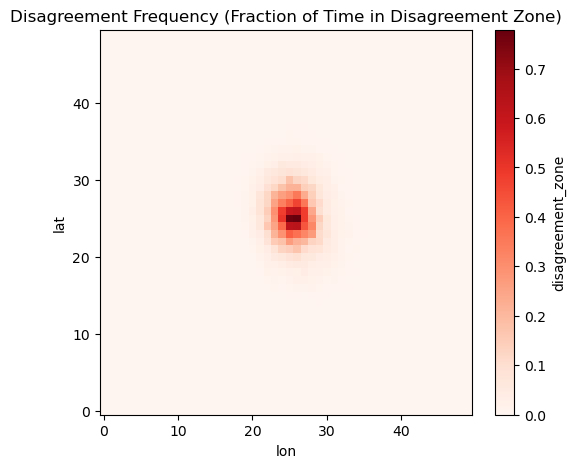

Saved disagreement_zone_frequency.png


In [ ]:
plt.figure(figsize=(6, 5))
disagreement_freq.plot(cmap="Reds")
plt.title("Disagreement Frequency (Fraction of Time in Disagreement Zone)")
plt.savefig(save_path("disagreement_zone_frequency.png"))
plt.show()
plt.close()
print("Saved disagreement_zone_frequency.png")

## Temporal uncertainty

### Uncertainty of ensemble

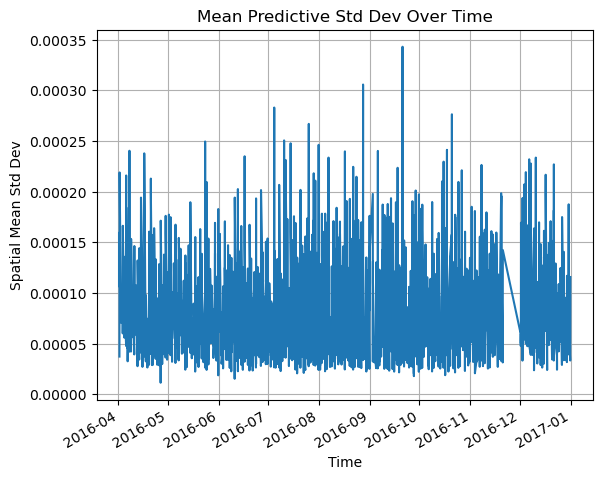

In [24]:
temporal_uncertainty = std_pred.mean(dim=("lat", "lon"))

plt.figure()
temporal_uncertainty.plot()
plt.title("Mean Predictive Std Dev Over Time")
plt.xlabel("Time")
plt.ylabel("Spatial Mean Std Dev")
plt.grid(True)
plt.savefig(save_path("temporal_std_dev.png"))
plt.show()
plt.close()


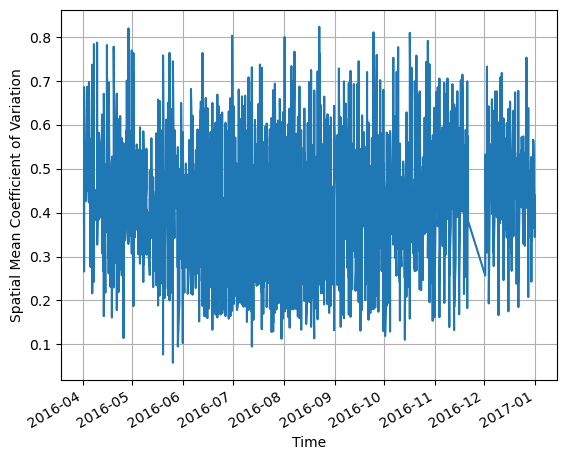

In [ ]:
temporal_uncertainty = cv_pred.mean(dim=("lat", "lon"))

plt.figure()
temporal_uncertainty.plot()
#plt.title("Mean Coefficient of Variation Over Time")
plt.xlabel("Time")
plt.ylabel("Spatial Mean Coefficient of Variation")
plt.grid(True)
plt.savefig(save_path("13temporal_cv.pdf"))
plt.show()
plt.close()

### And mean MAE of ensemble compared to true fps

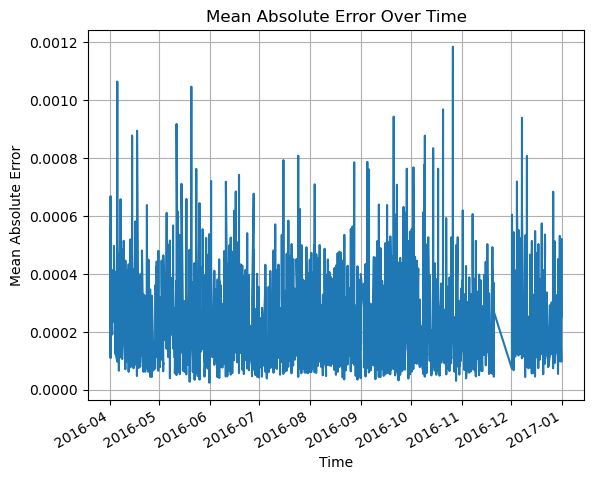

In [46]:
# Mean absolute error across space at each time step
temporal_mae = abs_error.mean(dim=("lat", "lon"))

# Plot
plt.figure()
temporal_mae.plot()
plt.title("Mean Absolute Error Over Time")
plt.xlabel("Time")
plt.ylabel("Mean Absolute Error")
plt.grid(True)
plt.savefig(save_path("temporal_mae.png"))
plt.show()
plt.close()

### Correlation Between Uncertainty and Error Over Time

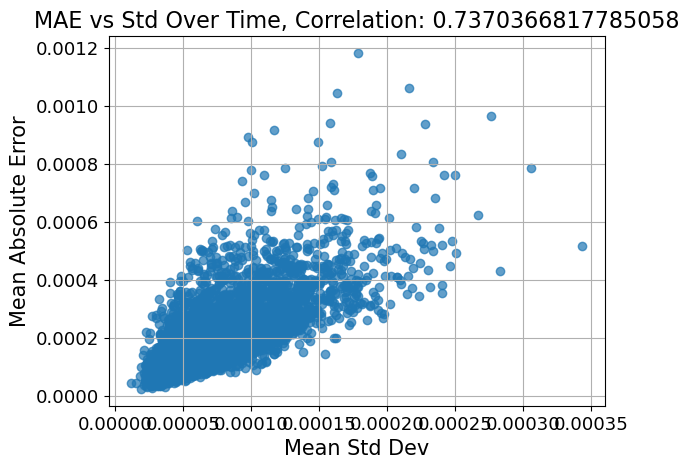

In [30]:
mae_over_time = abs_error.mean(dim=("lat", "lon"))
std_over_time = std_pred.mean(dim=("lat", "lon"))
corr_time = np.corrcoef(mae_over_time, std_over_time)[0, 1]

plt.figure()
plt.scatter(std_over_time, mae_over_time, alpha=0.7)
plt.title(f"MAE vs Std Over Time, Correlation: {corr_time}")
plt.xlabel("Mean Std Dev")
plt.ylabel("Mean Absolute Error")
plt.grid(True)
plt.savefig(save_path("mae_error_vs_uncertainty_time.png"))
plt.show()
plt.close()

### --- Run also for MSE and NMAE

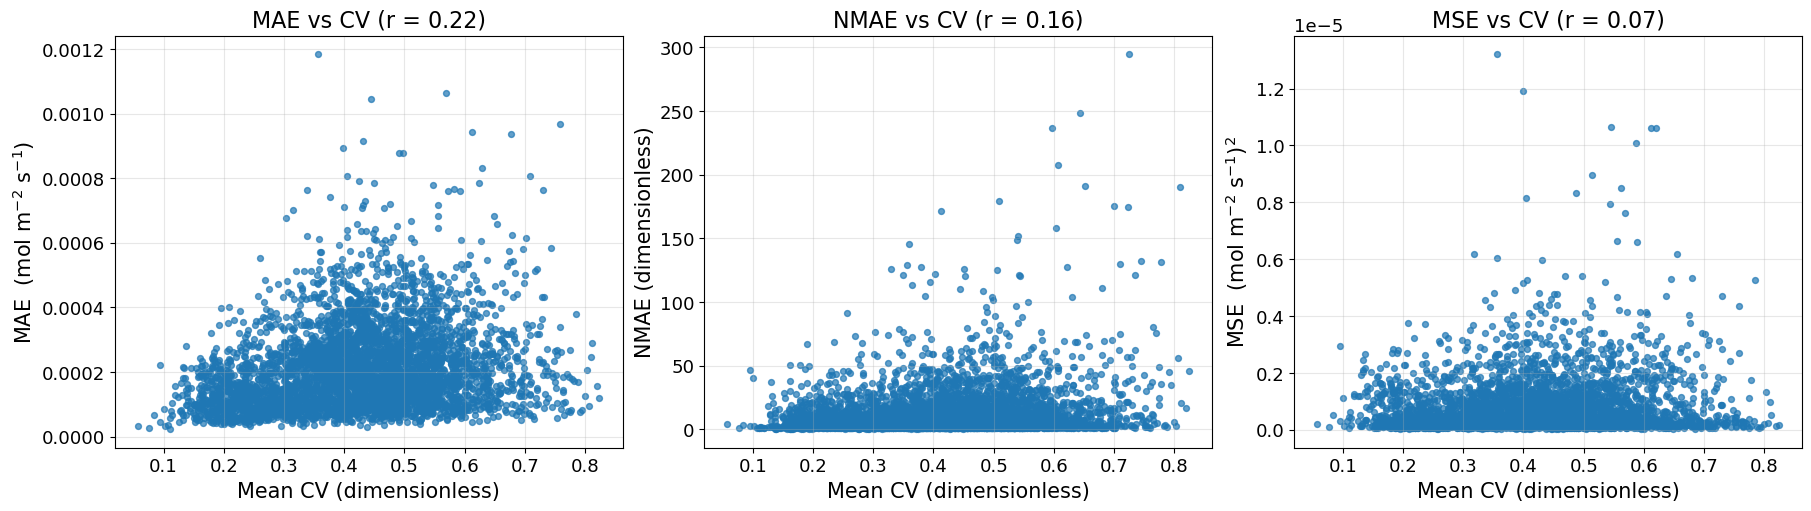

In [37]:
# --- Consistent τ (same idea you used earlier) -------------------------------
# Robust τ based on low quantile of positive truth across time/space
pos_truth = fp.where(fp > 0)
q5 = float(pos_truth.quantile(0.05).values) if np.isfinite(pos_truth.quantile(0.05)).all() else 0.0
tau = 0.1 * q5 if q5 > 0 else 1e-12

# --- Per-time spatial means ---------------------------------------------------
# CV (dimensionless)
cv_over_time  = cv_pred.mean(dim=("lat", "lon"))

# MAE (same units as fp)
mae_over_time = abs_error.mean(dim=("lat", "lon"))

# NMAE (dimensionless)
nmae_field    = abs_error / (fp + tau)
nmae_over_time = nmae_field.mean(dim=("lat", "lon"))

# MSE (squared units)
mse_field     = (mean_pred - fp) ** 2
mse_over_time = mse_field.mean(dim=("lat", "lon"))

# --- Correlations (filter finite pairs) --------------------------------------
def corr_valid(x_da, y_da):
    x = x_da.values.ravel()
    y = y_da.values.ravel()
    valid = np.isfinite(x) & np.isfinite(y)
    if valid.sum() < 2:
        return np.nan
    return float(np.corrcoef(x[valid], y[valid])[0, 1])

r_mae  = corr_valid(cv_over_time, mae_over_time)
r_nmae = corr_valid(cv_over_time, nmae_over_time)
r_mse  = corr_valid(cv_over_time, mse_over_time)

# --- Plot: 1×3 scatter panels -------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# 1) MAE vs CV
axes[0].scatter(cv_over_time, mae_over_time, alpha=0.7, s=18)
axes[0].set_title(f"MAE vs CV (r = {r_mae:.2f})")
axes[0].set_xlabel("Mean CV (dimensionless)")
axes[0].set_ylabel(r"MAE  ($\mathrm{mol\ m^{-2}\ s^{-1}}$)")
axes[0].grid(True, alpha=0.3)

# 2) NMAE vs CV
axes[1].scatter(cv_over_time, nmae_over_time, alpha=0.7, s=18)
axes[1].set_title(f"NMAE vs CV (r = {r_nmae:.2f})")
axes[1].set_xlabel("Mean CV (dimensionless)")
axes[1].set_ylabel("NMAE (dimensionless)")
axes[1].grid(True, alpha=0.3)

# 3) MSE vs CV
axes[2].scatter(cv_over_time, mse_over_time, alpha=0.7, s=18)
axes[2].set_title(f"MSE vs CV (r = {r_mse:.2f})")
axes[2].set_xlabel("Mean CV (dimensionless)")
axes[2].set_ylabel(r"MSE  $(\mathrm{mol\ m^{-2}\ s^{-1}})^2$")
axes[2].grid(True, alpha=0.3)

# (Optional) consistent x-limits across panels
# xmin = float(np.nanmin(cv_over_time))
# xmax = float(np.nanmax(cv_over_time))
# for ax in axes: ax.set_xlim(xmin, xmax)

plt.savefig(save_path("scatter_CV_vs_MAE_NMAE_MSE_over_time.png"), dpi=200)
plt.show()
plt.close()


In [51]:
## TO DO - compare to NMAE / MSE

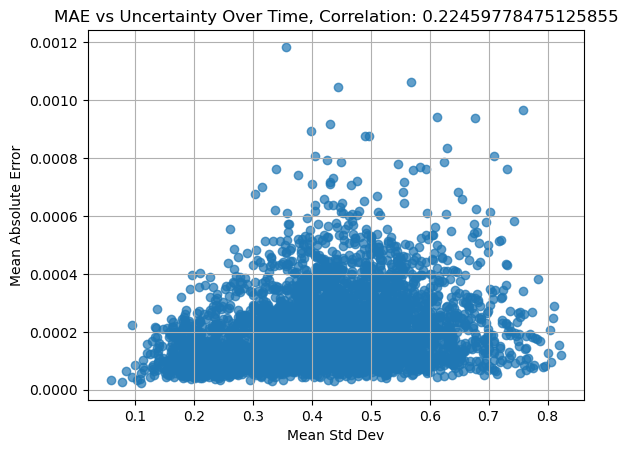

In [50]:
mae_over_time = abs_error.mean(dim=("lat", "lon"))
cv_over_time = cv_pred.mean(dim=("lat", "lon"))
corr_time = np.corrcoef(mae_over_time, cv_over_time)[0, 1]

plt.figure()
plt.scatter(cv_over_time, mae_over_time, alpha=0.7)
plt.title(f"MAE vs Uncertainty Over Time, Correlation: {corr_time}")
plt.xlabel("Mean Std Dev")
plt.ylabel("Mean Absolute Error")
plt.grid(True)
plt.savefig(save_path("mae_error_vs_cv_uncertainty_time.png"))
plt.show()
plt.close()

## Spatio-Temporal Consistency

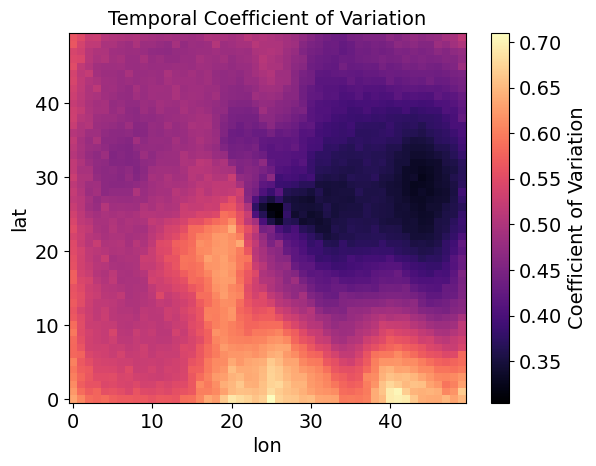

In [34]:
# Temporal standard deviation of uncertainty at each location
uncertainty_variability = std_pred.mean(dim="time")/ (mean_pred.mean(dim="time") + epsilon)  # Coefficient of Variation across time
#1408N
plt.figure()
p = uncertainty_variability.plot(cmap="magma")
p.colorbar.set_label("Coefficient of Variation")
plt.title("Temporal Coefficient of Variation")
plt.savefig(save_path("temporal_Coefficient_of_Variation_uncertainty.png"))
plt.show()
plt.close()

### Run for just a selected spatial region

In [ ]:
def spatial_sel(ds, lat, lon):
    lat = tuple(sorted(lat)) # put in ascending order
    lon = tuple(sorted(lon))  
    ds_sub = ds.sel(
    lat=slice(lat[0], lat[1]), 
    lon=slice(lon[0], lon[1])
)
    return ds_sub

real_sub = spatial_sel(real, (-24, -17), (-71, -64))
std_sel  = std_pred.sel(time=real_sub.time)
mean_sel = mean_pred.sel(time=real_sub.time)


NameError: name 'real' is not defined

In [ ]:
len(std_sel)

4169

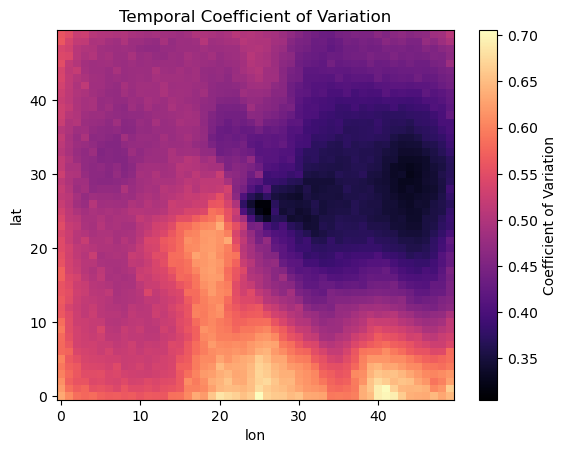

In [ ]:
# Temporal standard deviation of uncertainty at each location
uncertainty_variability = std_sel.mean(dim="time")/ mean_sel.mean(dim="time")  # Coefficient of Variation across time
#1408N
plt.figure()
p = uncertainty_variability.plot(cmap="magma")
p.colorbar.set_label("Coefficient of Variation")
plt.title("Temporal Coefficient of Variation")
plt.savefig(save_path("temporal_Coefficient_of_Variation_uncertainty_subsect.png"))
plt.show()
plt.close()

### Animated uncertainty visulation

In [ ]:
# These take a long time to run so I suggest not running them unless you want to see the animations
#animate_dataarray(mean_pred, "Mean Prediction", "mean_prediction.gif", cmap="viridis", save_dir=summary_dir)
#animate_dataarray(std_pred[0:100], "Standard Deviation[0:100]", "std_dev_over_time[0:100].gif", cmap="magma", save_dir=summary_dir)
#animate_dataarray(cv_pred[0:100], "Coefficient of Variation[0:100]", "cv_over_time[0:100].gif", cmap="cividis", save_dir=summary_dir)


# 3. Mole fractions

## Mole fractions using default uniform flux field, ie summing over the footprints

In [37]:
pred_mole_fractions, true_mole_fractions = get_all_mole_fractions(flux_type = "uniform")

median_true_flux = 2.013550900933654e-09

Loading cached mole fraction arrays from mole_fractions.npz...
Loaded shapes: pred=(4, 4243), true=(4, 4243)


In [ ]:
# Scale uniform flux values by true fluxes

cur_med = np.median(true_mole_fractions)
scale = median_true_flux / cur_med if cur_med != 0 else 0.0
scaled_uniform_mole_fractions = true_mole_fractions * scale

In [99]:
np.median(y_scaled) 

2.013550900933654e-09

### Plot for all models

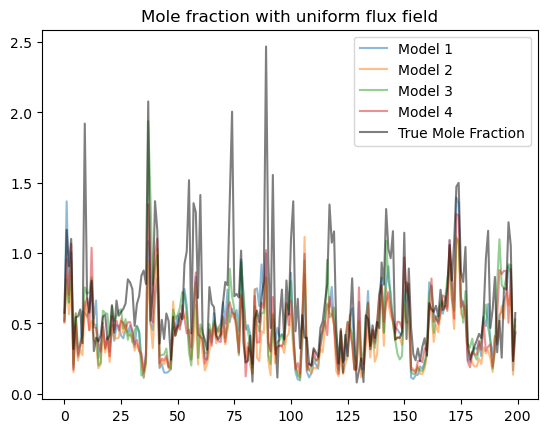

In [55]:
plot_mole_fraction(pred_mole_fractions, true_mole_fractions)

### Compute stats

In [28]:
mean_mole_fraction, std_mole_fraction, mean_true_mole_fraction, normalised_mean_mole_fraction, normalised_std_mole_fraction  = compute_mole_fraction_stats(pred_mole_fractions, true_mole_fractions)

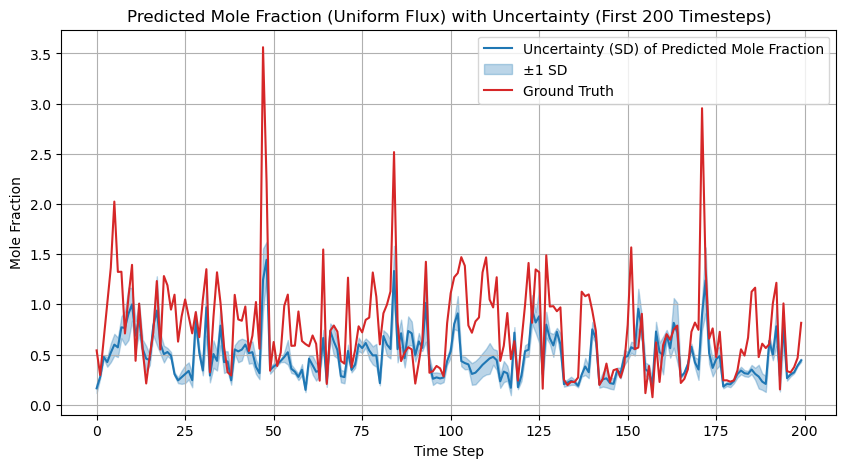

In [63]:
plot_mole_fraction_uncertainty(pred_mole_fractions, true_mole_fractions, plot="mean")

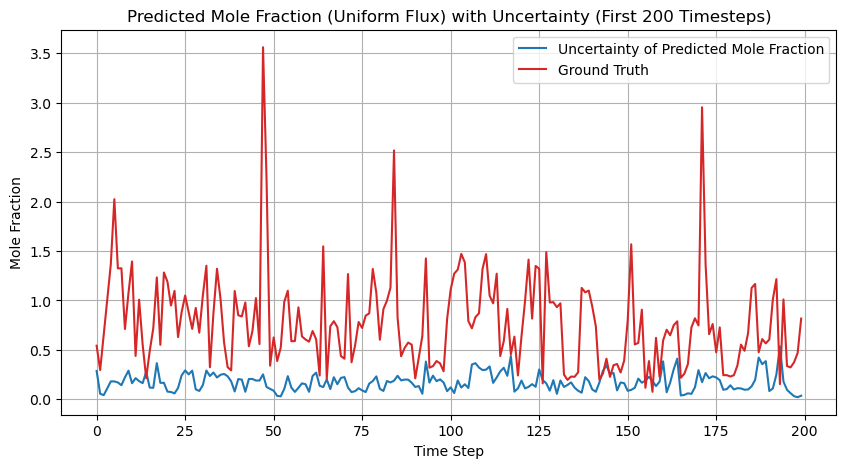

In [67]:
plot_mole_fraction_uncertainty(pred_mole_fractions, true_mole_fractions, plot="CV")

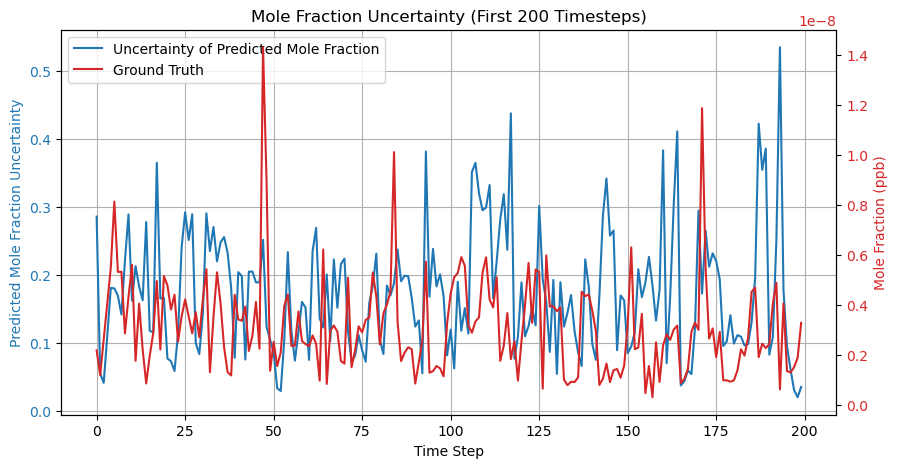

In [103]:
plot_normalised_mole_fraction_uncertainty(pred_mole_fractions, scaled_uniform_mole_fractions)

### Mole fraction prediction error vs uncertainty

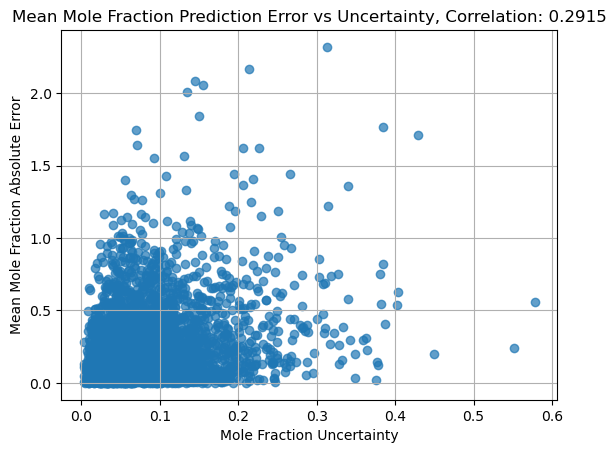

In [ ]:
#1408

abs_error = abs(mean_mole_fraction - mean_true_mole_fraction)
corr_time = np.corrcoef(abs_error, std_mole_fraction)[0, 1]

plt.figure()
plt.scatter(std_mole_fraction, abs_error, alpha=0.7)
plt.title(f"Mean Mole Fraction Prediction Error vs Uncertainty, Correlation: {corr_time:.4f}")
plt.xlabel("Mole Fraction Uncertainty")
plt.ylabel("Mean Mole Fraction Absolute Error")
plt.grid(True)
plt.savefig(save_path("abs_error_vs_uncertainty_mole_fractions.png"))
plt.show()
plt.close()

### Now find the extreme time steps with the largest uncertainty, and the lowest

In [ ]:
highest_uncertainty_indices, lowest_uncertainty_indices = find_extreme_mole_fraction_uncertainties(std_mole_fraction)

--- 10 highest uncertainties: ---
Time step 2476: std = 0.5780
Time step 2924: std = 0.5520
Time step 1764: std = 0.4496
Time step 3414: std = 0.4292
Time step 1339: std = 0.4040
Time step 727: std = 0.4026
Time step 93: std = 0.3868
Time step 3946: std = 0.3851
Time step 1434: std = 0.3839
Time step 2399: std = 0.3820
--- 10 lowest uncertainties: ---
Time step 250: std = 0.0032
Time step 3141: std = 0.0034
Time step 3984: std = 0.0036
Time step 1644: std = 0.0037
Time step 1822: std = 0.0038
Time step 3966: std = 0.0044
Time step 2897: std = 0.0046
Time step 2514: std = 0.0051
Time step 627: std = 0.0053
Time step 1969: std = 0.0061


--- 5 highest uncertainties: ---
Time step 2476: std = 0.5780
Time step 2924: std = 0.5520
Time step 1764: std = 0.4496
Time step 3414: std = 0.4292
Time step 1339: std = 0.4040
--- 5 lowest uncertainties: ---
Time step 250: std = 0.0032
Time step 3141: std = 0.0034
Time step 3984: std = 0.0036
Time step 1644: std = 0.0037
Time step 1822: std = 0.0038


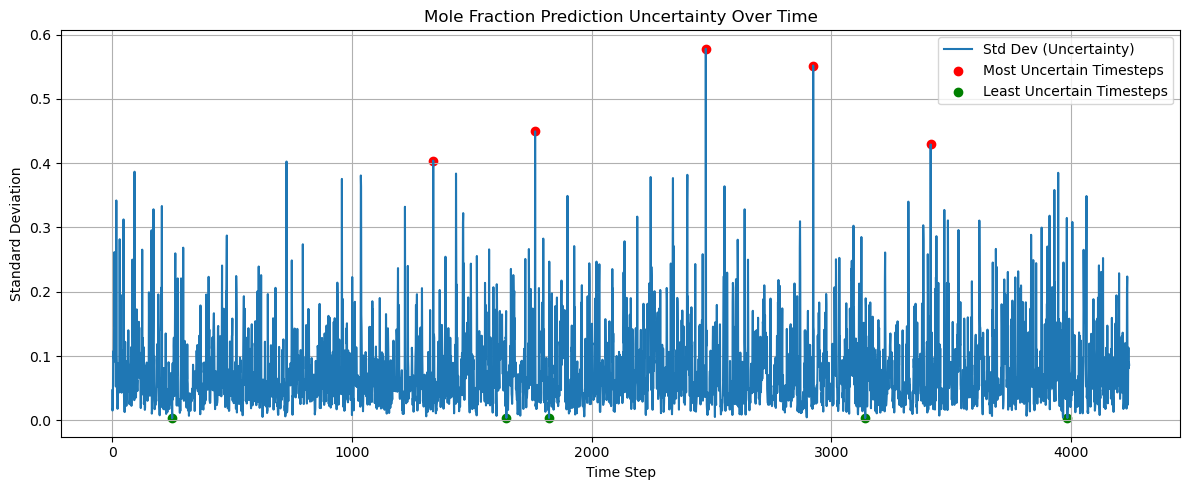

In [ ]:
plot_extreme_mole_fraction_uncertainties(std_mole_fraction, 5)

## Now load and cut the actual fluxes to get realistic above-baseline mole fractions

In [79]:
flux_type = "actual"

In [80]:
pred_mole_fractions, true_mole_fractions = get_all_mole_fractions(flux_type = flux_type)

Loading cached mole fraction arrays from mole_fractions_above_baseline.npz...
Loaded shapes: pred=(4, 4243), true=(4, 4243)


In [89]:
# calculate average baseline
from scipy import stats

flat1 = true_mole_fractions.flatten()
med = np.median(flat1)
mode = stats.mode(flat1)


In [90]:
med

2.013550900933654e-09

In [84]:
mode

ModeResult(mode=array([4.07822740e-10, 6.96590578e-10, 1.90440668e-09, ...,
       1.39038647e-08, 9.79172841e-09, 6.85383190e-09]), count=array([4., 4., 4., ..., 4., 4., 4.]))

In [ ]:
# compute stats
mean_mole_fractions, std_mole_fractions, mean_true_mole_fractions, normalised_mean_mole_fractions, normalised_std_mole_fractions = compute_mole_fraction_stats(pred_mole_fractions, true_mole_fractions)

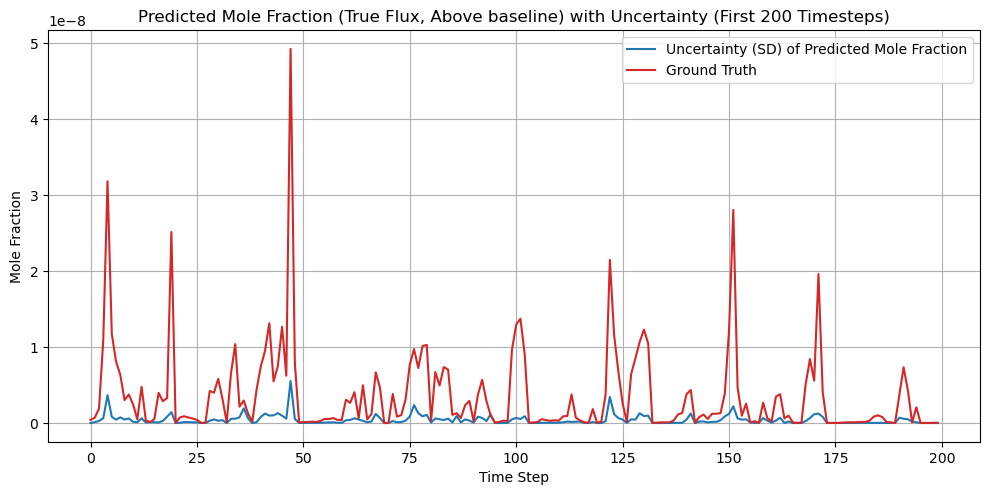

In [ ]:
# plot
plot_mole_fraction_uncertainty(pred_mole_fractions, true_mole_fractions, flux_type=flux_type)

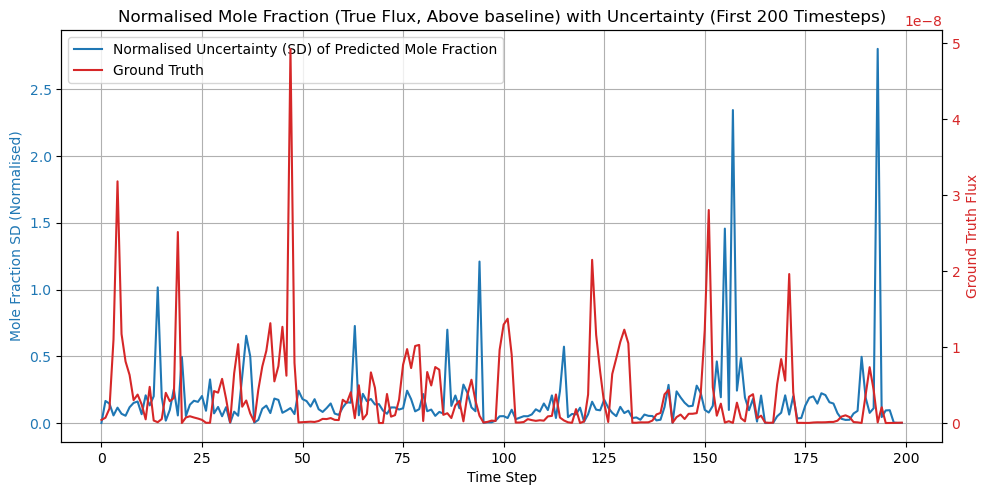

In [ ]:
plot_normalised_mole_fraction_uncertainty(pred_mole_fractions, true_mole_fractions, flux_type=flux_type)

In [ ]:
highest_uncertainty_indices, lowest_uncertainty_indices = find_extreme_mole_fraction_uncertainties(std_mole_fraction)

--- 10 highest uncertainties: ---
Time step 2476: std = 0.5780
Time step 2924: std = 0.5520
Time step 1764: std = 0.4496
Time step 3414: std = 0.4292
Time step 1339: std = 0.4040
Time step 727: std = 0.4026
Time step 93: std = 0.3868
Time step 3946: std = 0.3851
Time step 1434: std = 0.3839
Time step 2399: std = 0.3820
--- 10 lowest uncertainties: ---
Time step 250: std = 0.0032
Time step 3141: std = 0.0034
Time step 3984: std = 0.0036
Time step 1644: std = 0.0037
Time step 1822: std = 0.0038
Time step 3966: std = 0.0044
Time step 2897: std = 0.0046
Time step 2514: std = 0.0051
Time step 627: std = 0.0053
Time step 1969: std = 0.0061


--- 5 highest uncertainties: ---
Time step 827: std = 2.6212
Time step 1390: std = 2.2553
Time step 2022: std = 2.2419
Time step 3094: std = 2.0008
Time step 2375: std = 1.7785
--- 5 lowest uncertainties: ---
Time step 2514: std = 0.0057
Time step 3141: std = 0.0068
Time step 1145: std = 0.0090
Time step 544: std = 0.0092
Time step 1691: std = 0.0094


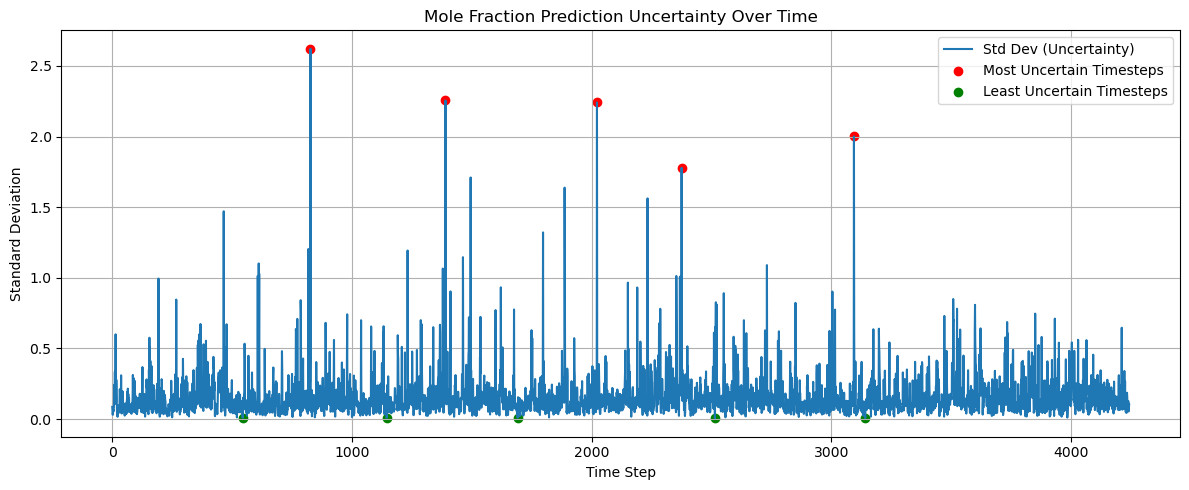

In [ ]:
plot_extreme_mole_fraction_uncertainties(normalised_std_mole_fraction, 5)

----

In [ ]:
# loads the brazil map of fluxes
brazil_fluxes = load_default_brazil_emissions()

# load the true footprints to use the release_lat and release_lon,
# and select the same timepoints as the testing set
true_fps = load_fps("/group/chemistry/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_2016*.nc")
true_fps = true_fps.sel(time=mod.preds_test.time)

cut_flux = cut_emissions_data(brazil_fluxes, true_fps, 50)
cut_flux = cut_flux.transpose([2,0,1])
# now cut_flux is in the same shape as mod.pred_fluxes["thr"], so we can plot it
mod.get_fluxes(cut_flux)

USING NO UNITS TRANSFORM on the fluxes! this may have changed


## Compute stats

## Now find the 10 time steps with the largest uncertainty, and the lowest

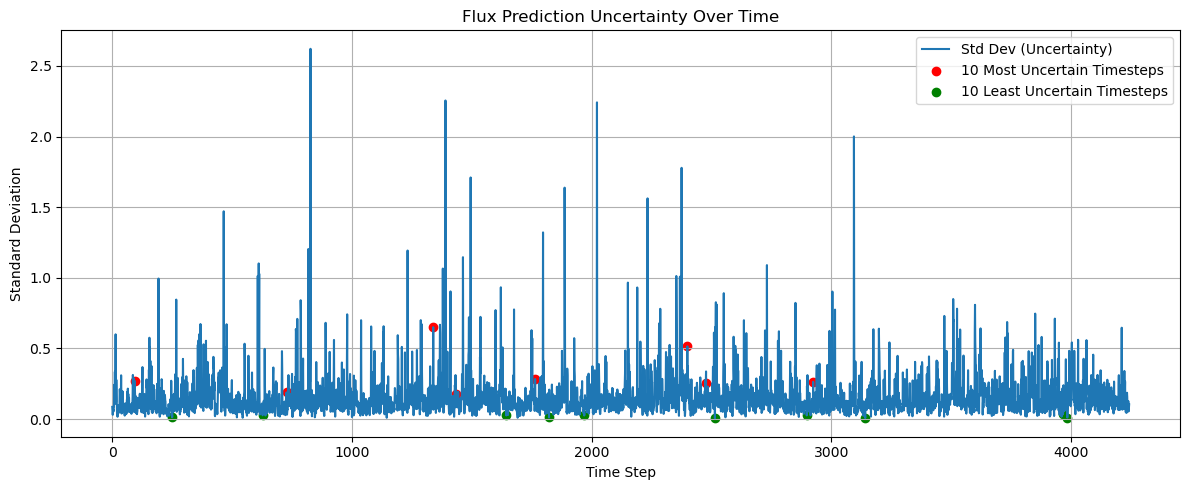

In [ ]:
time = np.arange(len(normalised_std_mole_fraction))
top_n = 10
plt.figure(figsize=(12, 5))
plt.plot(time, normalised_std_mole_fraction, label="Std Dev (Uncertainty)", color="tab:blue")

# Highlight top uncertain timesteps
plt.scatter(highest_uncertainty_indices, normalised_std_mole_fraction[highest_uncertainty_indices], color="red", label=f"{top_n} Most Uncertain Timesteps")
plt.scatter(lowest_uncertainty_indices, normalised_std_mole_fraction[lowest_uncertainty_indices], color="green", label=f"{top_n} Least Uncertain Timesteps")


plt.title("Flux Prediction Uncertainty Over Time")
plt.xlabel("Time Step")
plt.ylabel("Standard Deviation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(save_path("flux_timeseries_with_high_low_uncertainty_true.png"))
plt.show()

# 1. Time - seasonal analysis, starting with mole fractions

# 2. Space - Disaggregated map of errors

In [10]:
# Grab actual fp
month="*"
year="2016"
real = xr.open_mfdataset(glob.glob(f"/group/chemistry/acrg/LPDM/fp_Elena/satellite_emulated_logv4/NAME_fps_intersect_square/SOUTHAMERICA/GOSAT-BRAZIL-column_SOUTHAMERICA_{year}{month}.nc"))
domain_lats = real.lat.values
domain_lons = real.lon.values

In [11]:
# Choose an uncertainty layer (2D), eg
unc_cv   = cv_pred.mean(dim="time")               # mean coefficient of variation      (lat x lon)
unc_rng  = range_90.mean(dim="time")              # mean 90% prediction range          (lat x lon)
disc_frq = disagreement_mask.mean(dim="time")     # frequency of disagreement          (lat x lon), in [0,1]

## Footprints

### Spatial footprint SD

#### True fp

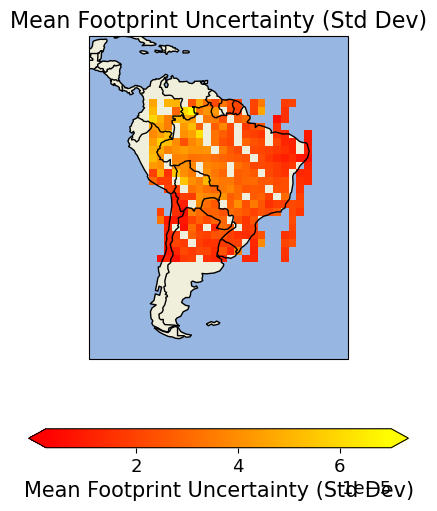

In [49]:
std_sel = real.sel(time=np.intersect1d(std_pred.time, real.time))

real = real.sel(time=np.intersect1d(std_pred.time, real.time))
uncertainty_per_footprint = real.fp.mean(dim=("lat", "lon")) #(a list of the uncertainty per footprint) --- Currently mean uncertainty 


release_lats = real.release_lat.values
release_lons = real.release_lon.values

# bins the data spatially
binned_data, lat_edges, lon_edges = bin_data(uncertainty_per_footprint, release_lats, release_lons, degree_bins=2)

fig, ax = plt.subplots(figsize=(7,6), subplot_kw={"projection": ccrs.PlateCarree()})
plot_binned_map(ax, lon_edges, lat_edges, binned_data, metric_name = "Mean Footprint Uncertainty (Std Dev)", extent="default", cut_lats=[0,0], title_modifier="", domain_lats=real.lat.values, domain_lons=real.lon.values, divergent=False, vmin_vmax = [np.nanpercentile(uncertainty_per_footprint, 1), np.nanpercentile(uncertainty_per_footprint, 99)], cmap="metrics", fig=fig, cbar=True)
plt.savefig(save_path("footprint_uncertainty_std_map.png"), dpi=200)
plt.show()

#### Predicted fp

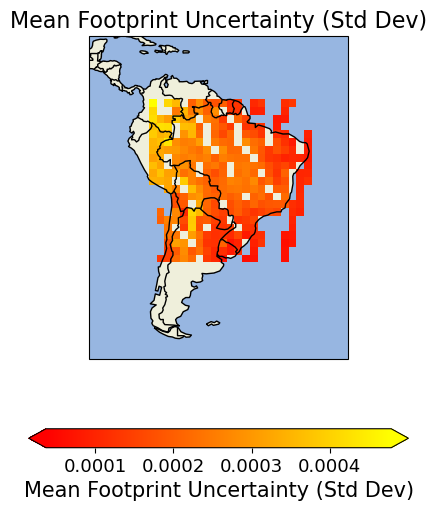

In [ ]:
std_sel = mean_pred.sel(time=np.intersect1d(std_pred.time, real.time))
uncertainty_per_footprint = std_sel.mean(dim=("lat", "lon")) #(a list of the uncertainty per footprint) --- Currently mean uncertainty 

real = real.sel(time=np.intersect1d(std_pred.time, real.time))

release_lats = real.release_lat.values
release_lons = real.release_lon.values

# bins the data spatially
binned_data, lat_edges, lon_edges = bin_data(uncertainty_per_footprint, release_lats, release_lons, degree_bins=2)

fig, ax = plt.subplots(figsize=(7,6), subplot_kw={"projection": ccrs.PlateCarree()})
plot_binned_map(ax, lon_edges, lat_edges, binned_data, metric_name = "Mean Footprint Uncertainty (Std Dev)", extent="default", cut_lats=[0,0], title_modifier="", domain_lats=real.lat.values, domain_lons=real.lon.values, divergent=False, vmin_vmax = [np.nanpercentile(uncertainty_per_footprint, 1), np.nanpercentile(uncertainty_per_footprint, 99)], cmap="metrics", fig=fig, cbar=True)
plt.savefig(save_path("footprint_uncertainty_std_map.png"), dpi=200)
plt.show()

### Uncertainty

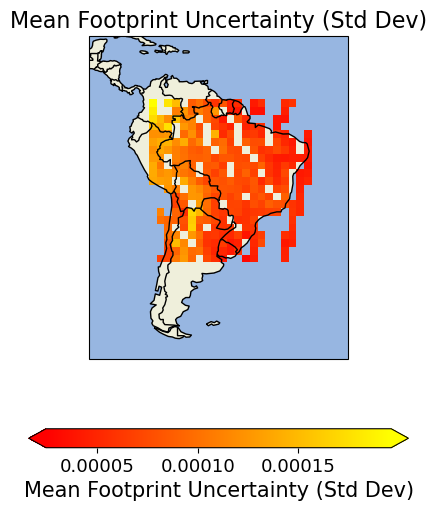

In [40]:
std_sel = std_pred.sel(time=np.intersect1d(std_pred.time, real.time))
uncertainty_per_footprint = std_sel.mean(dim=("lat", "lon")) #(a list of the uncertainty per footprint) --- Currently mean uncertainty 

real = real.sel(time=np.intersect1d(std_pred.time, real.time))

release_lats = real.release_lat.values
release_lons = real.release_lon.values

# bins the data spatially
binned_data, lat_edges, lon_edges = bin_data(uncertainty_per_footprint, release_lats, release_lons, degree_bins=2)

fig, ax = plt.subplots(figsize=(7,6), subplot_kw={"projection": ccrs.PlateCarree()})
plot_binned_map(ax, lon_edges, lat_edges, binned_data, metric_name = "Mean Footprint Uncertainty (Std Dev)", extent="default", cut_lats=[0,0], title_modifier="", domain_lats=real.lat.values, domain_lons=real.lon.values, divergent=False, vmin_vmax = [np.nanpercentile(uncertainty_per_footprint, 1), np.nanpercentile(uncertainty_per_footprint, 99)], cmap="metrics", fig=fig, cbar=True)
plt.savefig(save_path("footprint_uncertainty_std_map.png"), dpi=200)
plt.show()

In [22]:
from importlib import reload
from graphnet_LPDM_emulator.model.metrics_and_figures import *


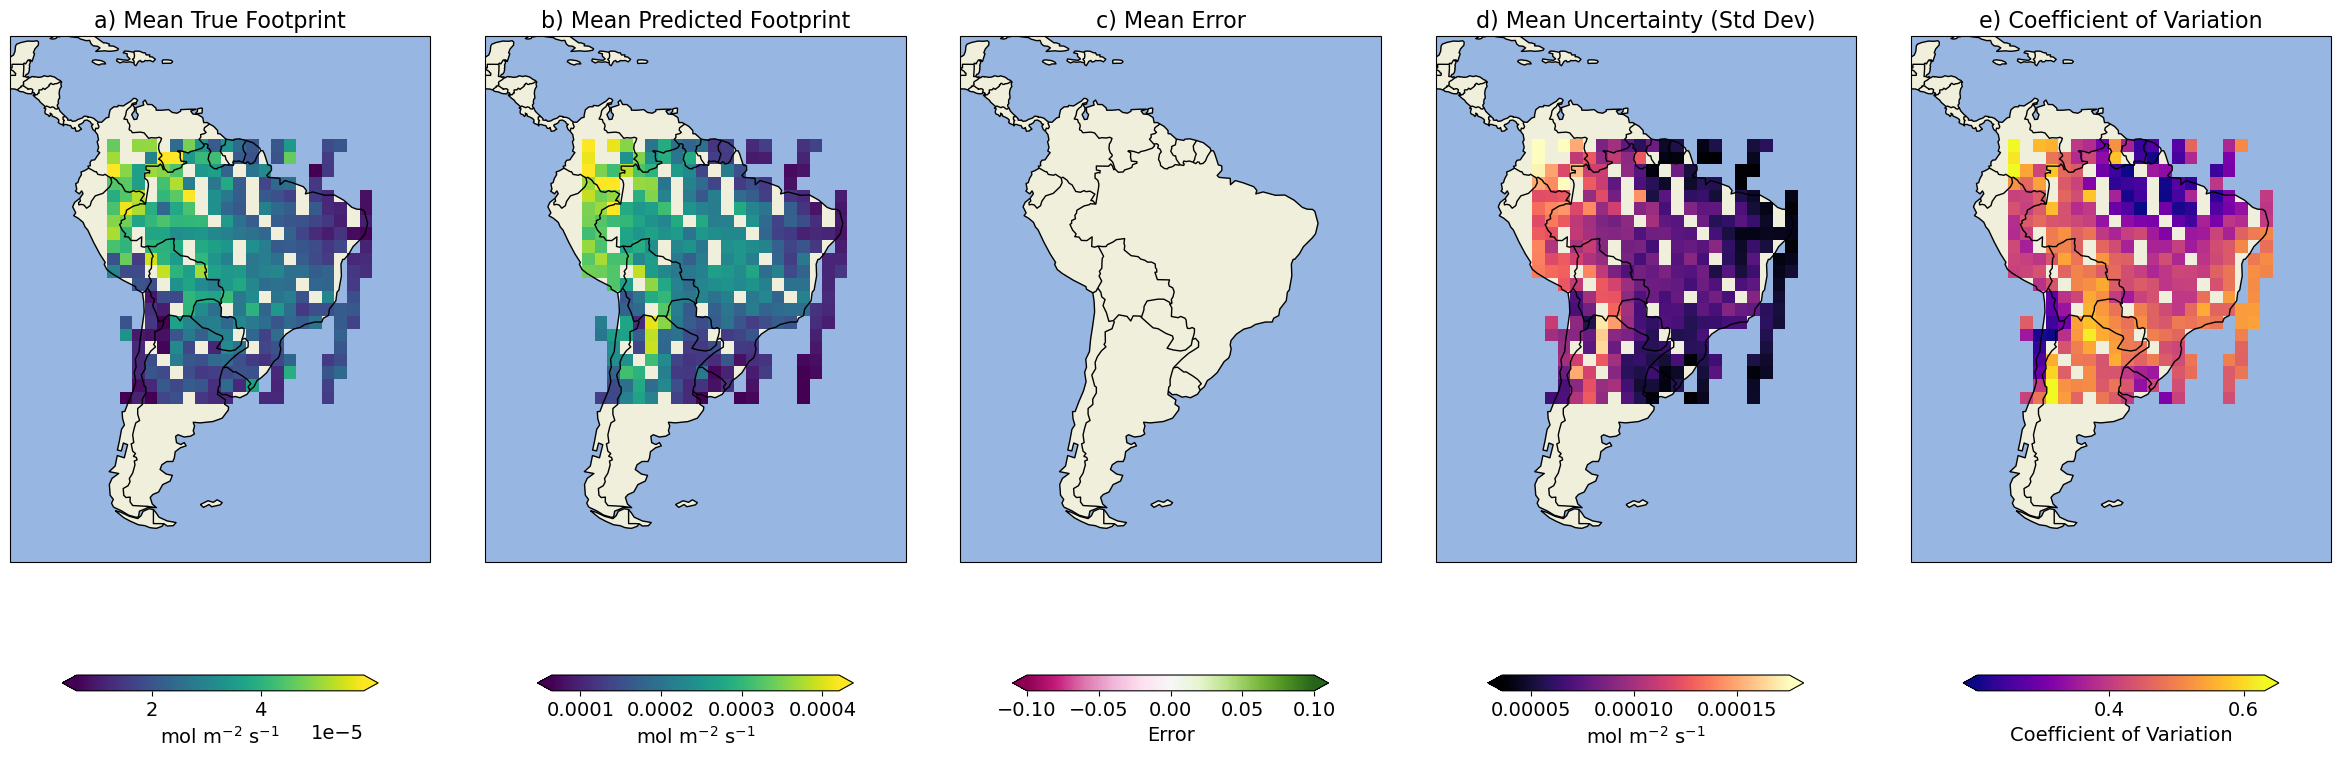

In [ ]:
plt.rcParams.update({"font.size": 16, "axes.titlesize": 16})

# --- Align time for everything ---
common_time = np.intersect1d(std_pred.time, real.time)
real_sel = real.sel(time=common_time)
mean_sel = mean_pred.sel(time=common_time)
std_sel  = std_pred.sel(time=common_time)
cv_sel = cv_pred.sel(time=common_time)

def make_binned_map(dataarray, release_lats, release_lons, title, cmap="metrics", divergent=False, cbar_label=None):
    """Compute spatial bins for a footprint-like DataArray and return plot-ready pieces."""
    per_footprint = dataarray.mean(dim=("lat", "lon"))
    binned_data, lat_edges, lon_edges = bin_data(
        per_footprint, release_lats, release_lons, degree_bins=2
    )
    return (binned_data, lat_edges, lon_edges, title, cmap, divergent, cbar_label)

release_lats = real_sel.release_lat.values
release_lons = real_sel.release_lon.values


# Panels
to_plot = [
    make_binned_map(real_sel.fp, release_lats, release_lons, "a) Mean True Footprint", cmap="viridis", cbar_label=r'$\mathrm{mol\ m^{-2}\ s^{-1}}$'),
    make_binned_map(mean_sel, release_lats, release_lons, "b) Mean Predicted Footprint", cmap="viridis", cbar_label=r'$\mathrm{mol\ m^{-2}\ s^{-1}}$'),
    make_binned_map(mean_sel - real_sel.fp, release_lats, release_lons, "c) Mean Error", cmap="coolwarm", divergent=True, cbar_label= 'Error'),
    make_binned_map(std_sel, release_lats, release_lons, "d) Uncertainty (Std Dev)", cmap="magma", cbar_label=r'$\mathrm{mol\ m^{-2}\ s^{-1}}$'),
    make_binned_map(cv_sel, release_lats, release_lons, "e) Uncertainty (CV)", cmap="plasma", cbar_label="Coefficient of Variation"),
]

# --- Plot 5 subplots ---------------------------------------------------------
fig, axes = plt.subplots(1, 5, figsize=(24, 8), subplot_kw={"projection": ccrs.PlateCarree()})

for ax, (binned_data, lat_edges, lon_edges, title, cmap, divergent, cbar_label) in zip(axes, to_plot):
    plot_binned_map(
        ax, lon_edges, lat_edges, binned_data,
        metric_name=title,
        extent="default",
        cut_lats=[0,0],
        title_modifier="",
        domain_lats=real_sel.lat.values,
        domain_lons=real_sel.lon.values,
        divergent=divergent,
        vmin_vmax=[
            np.nanpercentile(binned_data, 1),
            np.nanpercentile(binned_data, 99)
        ],
        cmap=cmap,
        fig=fig,
        cbar=True,
        cbar_label=cbar_label
    )
    ax.set_title(title)

plt.tight_layout()
plt.savefig(save_path("15fp_true_pred_error_uncertainty_cv_map.pdf"))
plt.show()

### And quarterly

/tmp/ipykernel_1994838/324715001.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = mpl.cm.get_cmap("metrics")
/tmp/ipykernel_1994838/324715001.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = mpl.cm.get_cmap("viridis")


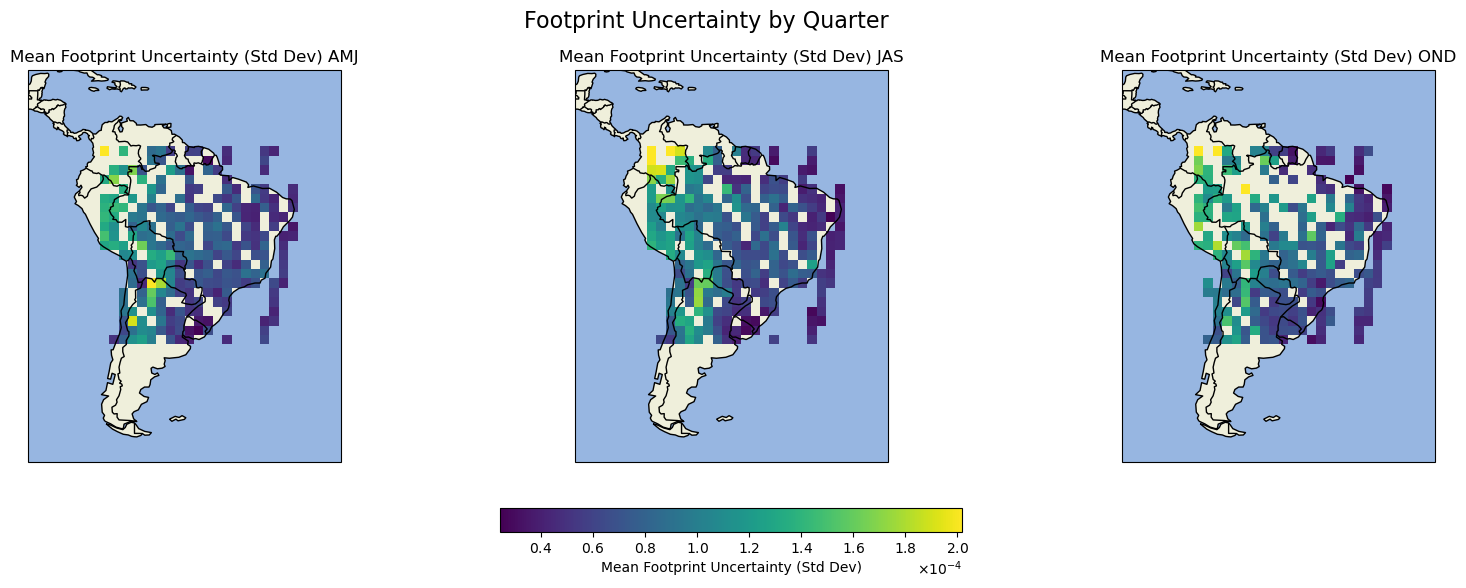

Saved uncertainty/summary_outputs/footprint_uncertainty_std_map_quarters.png


In [118]:
import matplotlib as mpl
from matplotlib.colors import Normalize

quarters = {
    "AMJ": [4, 5, 6],   # Apr–Jun
    "JAS": [7, 8, 9],   # Jul–Sep
    "OND": [10, 11, 12] # Oct–Dec
}

# Resolve colormap once (fallback to 'viridis' if 'metrics' isn't registered)
try:
    cmap_obj = mpl.cm.get_cmap("metrics")
except ValueError:
    cmap_obj = mpl.cm.get_cmap("viridis")

# Set up figure (3 subplots side-by-side)
fig, axes = plt.subplots(
    1, len(quarters), figsize=(20, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# If axes is a single Axes when len==1, normalize to iterable
if not isinstance(axes, (list, np.ndarray)):
    axes = [axes]

vmins, vmaxs = [], []
quarter_data = []

# --- First loop: collect quarter data and global vmin/vmax ---
for qlabel, months in quarters.items():
    mask = std_sel.time.dt.month.isin(months)
    if mask.sum().item() == 0:
        quarter_data.append((qlabel, None))
        continue

    std_q  = std_sel.sel(time=std_sel.time[mask])
    real_q = real.sel(time=real.time[mask])

    # Compute per-footprint uncertainty for this quarter
    unc_q = std_q.mean(dim=("lat", "lon"))

    # Bin using the release locations
    binned_data, lat_edges, lon_edges = bin_data(
        unc_q, real_q.release_lat.values, real_q.release_lon.values, degree_bins=2
    )

    quarter_data.append((qlabel, (binned_data, lat_edges, lon_edges, unc_q, real_q)))
    # Track percentiles for shared scale
    vmins.append(np.nanpercentile(unc_q, 1))
    vmaxs.append(np.nanpercentile(unc_q, 99))

# If nothing to plot, bail early
if len(vmins) == 0:
    for ax, (qlabel, _) in zip(axes, quarter_data):
        ax.set_title(f"{qlabel} (no data)")
    fig.suptitle("Footprint Uncertainty by Quarter — no data available", fontsize=16)
    plt.show()
else:
    vmin = float(np.min(vmins))
    vmax = float(np.max(vmaxs))
    norm = Normalize(vmin=vmin, vmax=vmax)

    # --- Second loop: plot into subplots ---
    for ax, (qlabel, qdata) in zip(axes, quarter_data):
        if qdata is None:
            ax.set_title(f"{qlabel} (no data)")
            continue

        binned_data, lat_edges, lon_edges, unc_q, real_q = qdata

        plot_binned_map(
            ax, lon_edges, lat_edges, binned_data,
            metric_name=f"Mean Footprint Uncertainty (Std Dev) {qlabel}",
            extent="default", cut_lats=[0, 0], title_modifier=f" | {qlabel}",
            domain_lats=real_q.lat.values, domain_lons=real_q.lon.values,
            divergent=False, vmin_vmax=[vmin, vmax],
            cmap=cmap_obj,            # <-- pass the cmap object
            fig=fig, cbar=False       # single shared cbar later
        )

    # Shared colourbar using the SAME cmap and norm
    mappable = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_obj)
    mappable.set_array([])  # required in some backends
    cbar = fig.colorbar(mappable, ax=axes, orientation="horizontal", fraction=0.05, pad=0.1)
    cbar.set_label("Mean Footprint Uncertainty (Std Dev)")
    cbar.formatter = mpl.ticker.ScalarFormatter(useMathText=True)
    cbar.formatter.set_powerlimits((-2, 2))
    cbar.update_ticks()

    fig.suptitle("Footprint Uncertainty by Quarter", fontsize=16)
    out = save_path("footprint_uncertainty_std_map_quarters.png")
    plt.savefig(out, dpi=200)
    plt.show()
    print(f"Saved {out}")


### And repeat for coefficient of variation

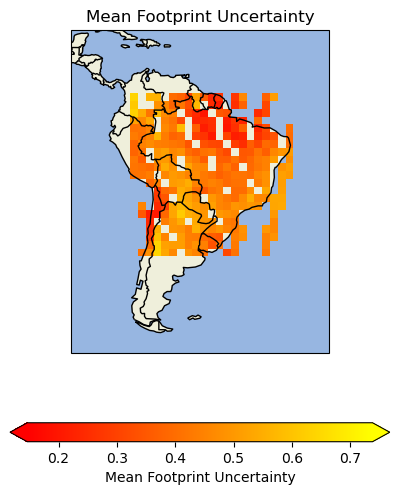

In [22]:
metric_sel = cv_pred.sel(time=np.intersect1d(cv_pred.time, real.time))
uncertainty_per_footprint = metric_sel.mean(dim=("lat", "lon")) #(a list of the uncertainty per footprint) --- Currently mean uncertainty 

real = real.sel(time=np.intersect1d(cv_pred.time, real.time))

release_lats = real.release_lat.values
release_lons = real.release_lon.values

# bins the data spatially
binned_data, lat_edges, lon_edges = bin_data(uncertainty_per_footprint, release_lats, release_lons, degree_bins=2)

fig, ax = plt.subplots(figsize=(7,6), subplot_kw={"projection": ccrs.PlateCarree()})
plot_binned_map(ax, lon_edges, lat_edges, binned_data, metric_name = "Mean Footprint Uncertainty", extent="default", cut_lats=[0,0], title_modifier="", domain_lats=real.lat.values, domain_lons=real.lon.values, divergent=False, vmin_vmax = [np.nanpercentile(uncertainty_per_footprint, 1), np.nanpercentile(uncertainty_per_footprint, 99)], cmap="metrics", fig=fig, cbar=True)
plt.savefig(save_path("footprint_uncertainty_cv_map.png"), dpi=200)
plt.show()

/tmp/ipykernel_2097752/1698505464.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = mpl.cm.get_cmap("metrics")
/tmp/ipykernel_2097752/1698505464.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = mpl.cm.get_cmap("viridis")


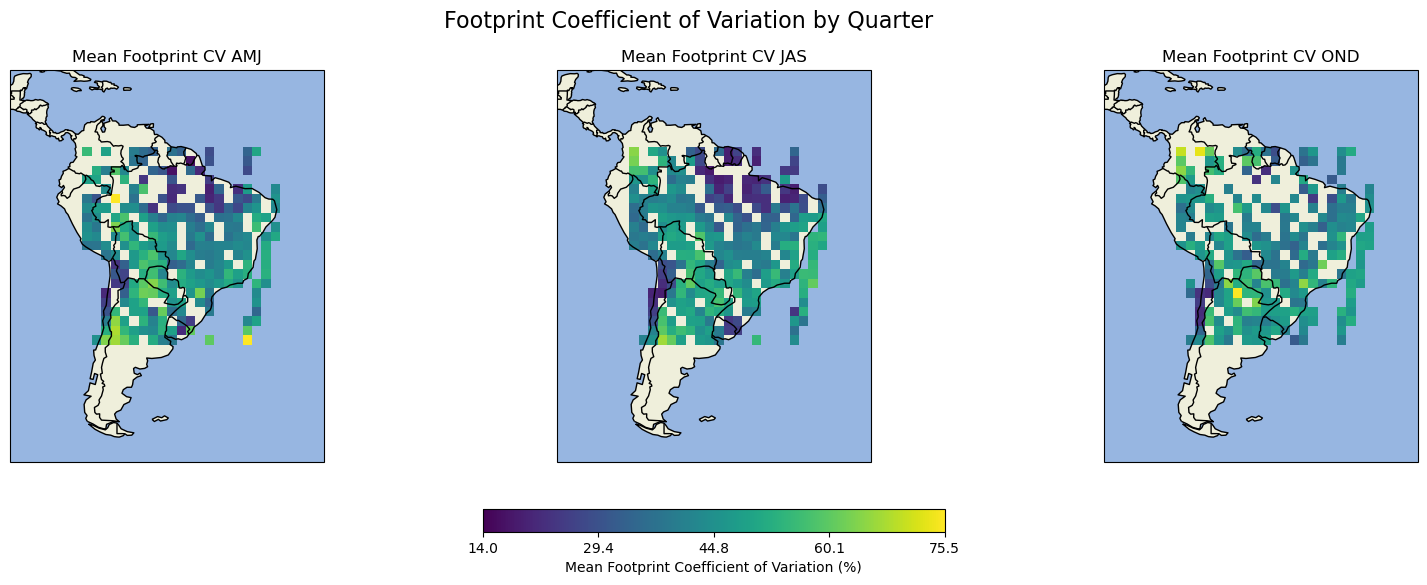

Saved uncertainty/summary_outputs/footprint_uncertainty_cv_map_quarters.png


In [20]:
import matplotlib as mpl
from matplotlib.colors import Normalize

# ------------- settings -------------
AS_PERCENT = True  # set False to keep CV as a ratio (0–1)
quarters = {"AMJ":[4,5,6], "JAS":[7,8,9], "OND":[10,11,12]}

# Select times present in both
metric_sel = cv_pred.sel(time=np.intersect1d(cv_pred.time, real.time))

# Colormap (fallback)
try:
    cmap_obj = mpl.cm.get_cmap("metrics")
except ValueError:
    cmap_obj = mpl.cm.get_cmap("viridis")

# Figure with 3 subplots
fig, axes = plt.subplots(
    1, len(quarters), figsize=(20, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
if not isinstance(axes, (list, np.ndarray)):
    axes = [axes]

vmins, vmaxs = [], []
quarter_data = []

# -------- collect data & global vmin/vmax --------
for qlabel, months in quarters.items():
    mask = metric_sel.time.dt.month.isin(months)
    if mask.sum().item() == 0:
        quarter_data.append((qlabel, None))
        continue

    metric_q = metric_sel.sel(time=metric_sel.time[mask])  # CV time series (lat, lon, time or similar)
    real_q   = real.sel(time=real.time[mask])

    # Per-footprint CV: average over spatial dims to 1D (time-aligned)
    cv_pf = metric_q.mean(dim=("lat", "lon"))

    # Optional: convert to %
    if AS_PERCENT:
        cv_plot = 100.0 * cv_pf
    else:
        cv_plot = cv_pf

    # Bin to release locations
    binned_data, lat_edges, lon_edges = bin_data(
        cv_plot, real_q.release_lat.values, real_q.release_lon.values, degree_bins=2
    )

    quarter_data.append((qlabel, (binned_data, lat_edges, lon_edges, cv_plot, real_q)))
    vmins.append(np.nanpercentile(cv_plot, 1))
    vmaxs.append(np.nanpercentile(cv_plot, 99))

if len(vmins) == 0:
    for ax, (qlabel, _) in zip(axes, quarter_data):
        ax.set_title(f"{qlabel} (no data)")
    fig.suptitle("Footprint CV by Quarter — no data available", fontsize=16)
    plt.show()
else:
    vmin = float(np.min(vmins))
    vmax = float(np.max(vmaxs))
    norm = Normalize(vmin=vmin, vmax=vmax)

    # -------- plot each quarter --------
    for ax, (qlabel, qdata) in zip(axes, quarter_data):
        if qdata is None:
            ax.set_title(f"{qlabel} (no data)")
            continue

        binned_data, lat_edges, lon_edges, cv_plot, real_q = qdata

        plot_binned_map(
            ax, lon_edges, lat_edges, binned_data,
            metric_name=f"Mean Footprint CV {qlabel}",
            extent="default", cut_lats=[0, 0], title_modifier=f" | {qlabel}",
            domain_lats=real_q.lat.values, domain_lons=real_q.lon.values,
            divergent=False, vmin_vmax=[vmin, vmax],
            cmap=cmap_obj, fig=fig, cbar=False
        )

    # -------- shared colorbar --------
    mappable = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_obj)
    mappable.set_array([])
    cbar = fig.colorbar(mappable, ax=axes, orientation="horizontal", fraction=0.05, pad=0.1)

    if AS_PERCENT:
        cbar.set_label("Mean Footprint Coefficient of Variation (%)")
        # clean ticks for % scale
        cbar.set_ticks(np.linspace(vmin, vmax, 5))
        cbar.ax.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.1f"))
    else:
        cbar.set_label("Mean Footprint Coefficient of Variation")
        cbar.formatter = mpl.ticker.ScalarFormatter(useMathText=True)
        cbar.formatter.set_powerlimits((-2, 2))
        cbar.update_ticks()

    fig.suptitle("Footprint Coefficient of Variation by Quarter", fontsize=16)
    out = save_path("footprint_uncertainty_cv_map_quarters.png")
    plt.savefig(out, dpi=200)
    plt.show()
    print(f"Saved {out}")


## Mole fraction

In [29]:
mean_mole_fraction, std_mole_fraction, mean_true_mole_fraction, normalised_mean_mole_fraction, normalised_std_mole_fraction  = compute_mole_fraction_stats(pred_mole_fractions, true_mole_fractions)

/tmp/ipykernel_2097752/3734495081.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = mpl.cm.get_cmap("metrics")
/tmp/ipykernel_2097752/3734495081.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = mpl.cm.get_cmap("viridis")


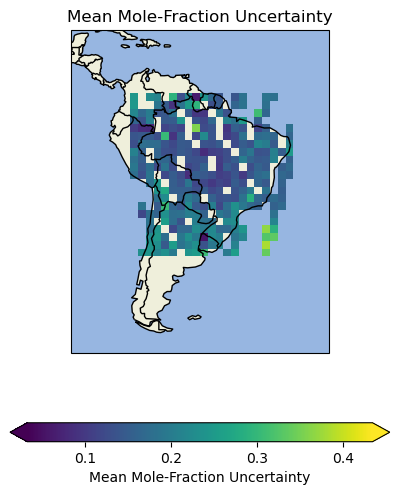

In [ ]:
# --- Mole-fraction uncertainty → spatial binned map ---

# 1) Wrap your 1-D uncertainty over time (std across seeds) as a DataArray with a time coord
#    If you already have `models` from earlier, the first model's preds_test.time is convenient.
mf_time = models[0][1].preds_test.time  # xarray time coordinate
mf_unc_std = xr.DataArray(std_mole_fraction, coords={"time": mf_time}, dims=["time"])
# (Optional) If you prefer CV for uncertainty instead of raw std, use this instead:
mf_unc_std = xr.DataArray(std_mole_fraction / (mean_mole_fraction + 1e-12),
                           coords={"time": mf_time}, dims=["time"])

# 2) Align to the LPDM "real" dataset times (release locations live here)
#    If 'real' isn’t loaded yet, load it like you did previously for the CV maps.
#    e.g.:
# real = xr.open_mfdataset(glob.glob(f"/group/chemistry/acrg/LPDM/fp_Elena/satellite_emulated_logv4/NAME_fps_intersect_square/SOUTHAMERICA/GOSAT-BRAZIL-column_SOUTHAMERICA_{year}{month}.nc"))

common_time = np.intersect1d(mf_unc_std.time, real.time)
mf_unc_std  = mf_unc_std.sel(time=common_time)
real_aligned = real.sel(time=common_time)

# 3) Extract release locations for each footprint/time
release_lats = real_aligned.release_lat.values
release_lons = real_aligned.release_lon.values

# 4) Bin the per-timestep uncertainty by release location
#    bin_data expects a 1-D series aligned with release_lats/lons (one value per time step)
binned_data, lat_edges, lon_edges = bin_data(mf_unc_std, release_lats, release_lons, degree_bins=2)

# 5) Plot
import matplotlib as mpl
try:
    cmap_obj = mpl.cm.get_cmap("metrics")
except ValueError:
    cmap_obj = mpl.cm.get_cmap("viridis")

vmin = float(np.nanpercentile(mf_unc_std.values, 1))
vmax = float(np.nanpercentile(mf_unc_std.values, 98))

fig, ax = plt.subplots(figsize=(7, 6), subplot_kw={"projection": ccrs.PlateCarree()})
plot_binned_map(
    ax, lon_edges, lat_edges, binned_data,
    metric_name="Mean Mole-Fraction Uncertainty",
    extent="default", cut_lats=[0, 0], title_modifier="",
    domain_lats=real_aligned.lat.values, domain_lons=real_aligned.lon.values,
    divergent=False, vmin_vmax=[vmin, vmax],
    cmap=cmap_obj, fig=fig, cbar=True
)
plt.savefig(save_path("33_uncertainty_mole_fraction_cv_map.png"), dpi=200)
plt.show()


/tmp/ipykernel_2097752/2955116394.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = mpl.cm.get_cmap("metrics")
/tmp/ipykernel_2097752/2955116394.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = mpl.cm.get_cmap("viridis")


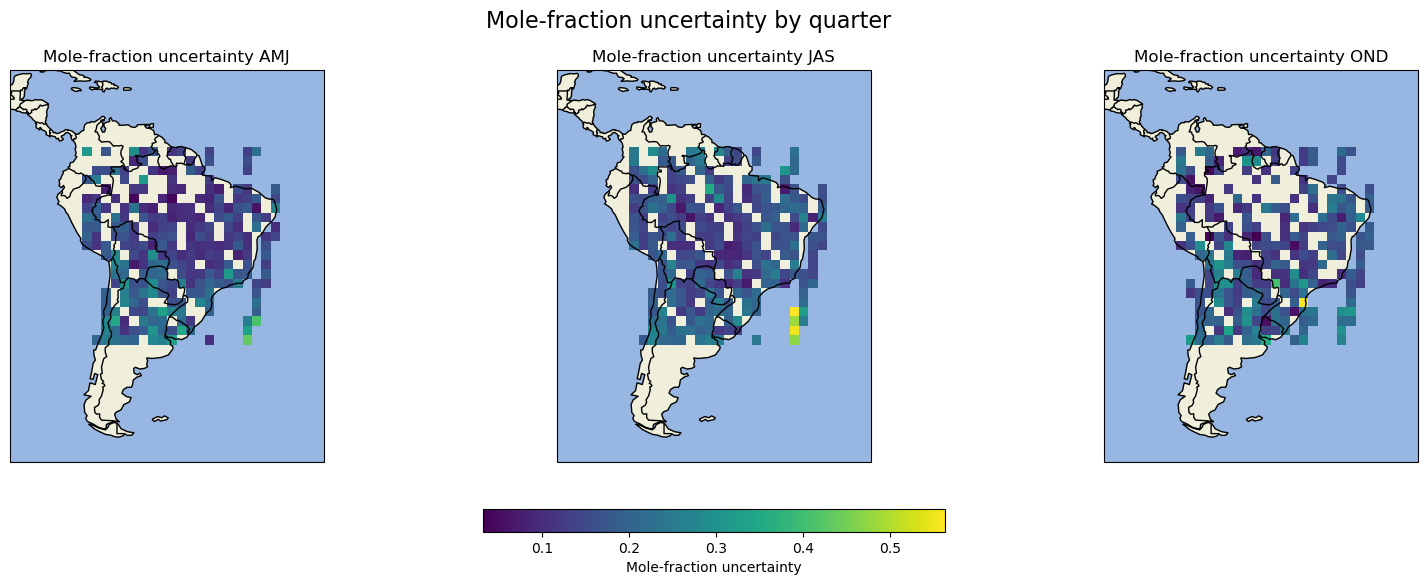

Saved uncertainty/summary_outputs/33uncertainty_mole_fraction_quarters.png


In [42]:
# --- Quarterly binned maps for mole-fraction uncertainty ---

# Build/align the 1-D time series of mole-fraction uncertainty (std across seeds)
mf_time = models[0][1].preds_test.time
mf_unc_std = xr.DataArray(std_mole_fraction, coords={"time": mf_time}, dims=["time"])

# Optional: use CV instead of std
mf_unc_std = xr.DataArray(std_mole_fraction / (mean_mole_fraction + 1e-12),
                           coords={"time": mf_time}, dims=["time"])

common_time = np.intersect1d(mf_unc_std.time, real.time)
mf_unc_std  = mf_unc_std.sel(time=common_time)
real_qbase  = real.sel(time=common_time)

quarters = {"AMJ":[4,5,6], "JAS":[7,8,9], "OND":[10,11,12]}

import matplotlib as mpl
from matplotlib.colors import Normalize
try:
    cmap_obj = mpl.cm.get_cmap("metrics")
except ValueError:
    cmap_obj = mpl.cm.get_cmap("viridis")

vmins, vmaxs = [], []
quarter_payload = []

for qlabel, months in quarters.items():
    mask = mf_unc_std.time.dt.month.isin(months)
    if mask.sum().item() == 0:
        quarter_payload.append((qlabel, None))
        continue

    mf_q   = mf_unc_std.sel(time=mf_unc_std.time[mask])
    real_q = real_qbase.sel(time=real_qbase.time[real_qbase.time.dt.month.isin(months)])

    release_lats = real_q.release_lat.values
    release_lons = real_q.release_lon.values

    binned_data, lat_edges, lon_edges = bin_data(mf_q, release_lats, release_lons, degree_bins=2)

    quarter_payload.append((qlabel, (binned_data, lat_edges, lon_edges, real_q)))
    vmins.append(np.nanpercentile(mf_q.values, 1))
    vmaxs.append(np.nanpercentile(mf_q.values, 99))

# Handle “no data at all” case
fig, axes = plt.subplots(1, len(quarters), figsize=(20, 6), subplot_kw={"projection": ccrs.PlateCarree()})
if not isinstance(axes, (list, np.ndarray)):
    axes = [axes]

if len(vmins) == 0:
    for ax, (qlabel, _) in zip(axes, quarter_payload):
        ax.set_title(f"{qlabel} (no data)")
    plt.suptitle("Mole-fraction uncertainty by quarter — no data available", fontsize=16)
    plt.show()
else:
    vmin = float(np.min(vmins))
    vmax = float(np.max(vmaxs))
    norm = Normalize(vmin=vmin, vmax=vmax)

    for ax, (qlabel, payload) in zip(axes, quarter_payload):
        if payload is None:
            ax.set_title(f"{qlabel} (no data)")
            continue

        binned_data, lat_edges, lon_edges, real_q = payload

        plot_binned_map(
            ax, lon_edges, lat_edges, binned_data,
            metric_name=f"Mole-fraction uncertainty {qlabel}",
            extent="default", cut_lats=[0, 0], title_modifier=f" | {qlabel}",
            domain_lats=real_q.lat.values, domain_lons=real_q.lon.values,
            divergent=False, vmin_vmax=[vmin, vmax],
            cmap=cmap_obj, fig=fig, cbar=False
        )

    mappable = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_obj)
    mappable.set_array([])
    cbar = fig.colorbar(mappable, ax=axes, orientation="horizontal", fraction=0.05, pad=0.1)
    cbar.set_label("Mole-fraction uncertainty")  # change if you used CV

    fig.suptitle("Mole-fraction uncertainty by quarter", fontsize=16)
    out = save_path("33uncertainty_mole_fraction_quarters.png")
    plt.savefig(out, dpi=200)
    plt.show()
    print(f"Saved {out}")


# 3. Relation with meterology

In [ ]:
# Compare uniform flux uncertainties to wind speed/direction at release point

In [27]:
# Load met data
met_data = xr.open_mfdataset(
    glob.glob("/group/chemistry/acrg/met_archive/UM/SOUTHAMERICA/*20160[4-9].nc")
    + glob.glob("/group/chemistry/acrg/met_archive/UM/SOUTHAMERICA/*20161[0-2].nc"),
    combine="by_coords"
)


Central lat/lon: -19.32900047302246 -49.0890007019043


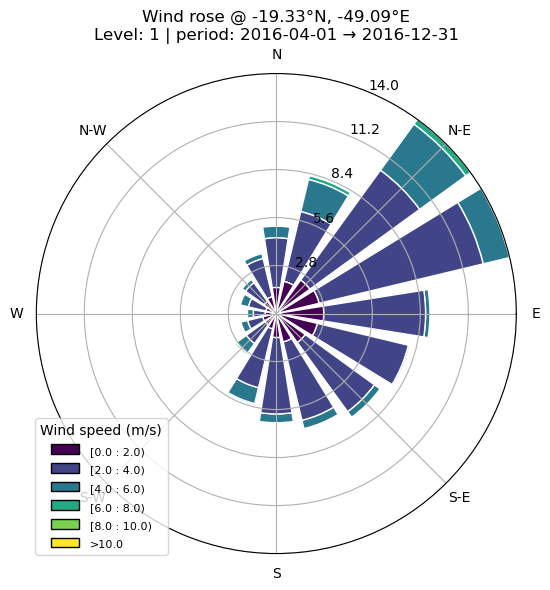

In [ ]:
# Create wind rose
from windrose import WindroseAxes

# --- inputs you set ---
ds = met_data  # replace with your loaded xarray Dataset

# find central indices
ilat = len(ds.latitude) // 2
ilon = len(ds.longitude) // 2

# extract central coords
lat_c = float(ds.latitude.isel(latitude=ilat))
lon_c = float(ds.longitude.isel(longitude=ilon))

print("Central lat/lon:", lat_c, lon_c)

# --- pick the lowest model level ---
# If level_height is height above ground, the lowest is the minimum:
low_lev = ds.level_height.idxmin('model_level_number')

u = ds.x_wind.sel(model_level_number=low_lev).isel(latitude=ilat, longitude=ilon)
v = ds.y_wind.sel(model_level_number=low_lev).isel(latitude=ilat, longitude=ilon)

# Dask -> NumPy (compute only what we need)
u1d = u.load().values.ravel()
v1d = v.load().values.ravel()

# Speed (m/s):
ws = np.hypot(u1d, v1d)

# Direction in degrees FROM North, clockwise (0..360):
# Using the usual meteorological convention: dir_from = atan2(-u, -v)
wd_from = (np.degrees(np.arctan2(-u1d, -v1d)) + 360) % 360

# --- plot wind rose ---
fig = plt.figure(figsize=(6, 6))
ax = WindroseAxes.from_ax(fig=fig)
# bins in m/s; adjust to suit your data range
speed_bins = np.arange(0, 10+1, 2)
ax.bar(wd_from, ws, bins=speed_bins, opening=0.8, edgecolor='white', normed=True)  # % frequencies
ax.set_legend(title="Wind speed (m/s)")
ax.set_title(f"Wind rose @ {float(u.latitude.values):.2f}°N, {float(u.longitude.values):.2f}°E\n"
             f"Level: {int(low_lev.values)} | period: {str(u.time.values[0])[:10]} → {str(u.time.values[-1])[:10]}")
plt.savefig(save_path("3wind_rose.pdf"), dpi=200)
plt.show()



# Legacy code (Elena's original notebook content)
## loading the data for one of the models

In [9]:
model_name = "satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed5"
mod = ModelEv(model_name, size=50, validation_set="0[1-3]", test_set="*", val_year="2016", test_year="2016", check_validation_overlap=True, path_to_files="/group/chemistry/acrg/ef17148/trained_satellite_models/")
# loads the model into a ModelEv object. by default it has the parameters above, which validate on Jan-March (stored in mod.preds_val) and keeps the rest in mod.preds_test 
# setting "check_validation_overlap=False" will keep all the footprints in mod.preds_test

loading data from /group/chemistry/acrg/ef17148/trained_satellite_models/satellite_clever2_50_[[]6,12[]]_vB_logv3_weightedbytruth_assym_C_seed5/predictions/preds_2016*.nc
using validation data: 20160[1-3] and test data: 2016*. Checking overlap between the two: True


/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 311 times more chunks
  return self.array[key]


In [ ]:
"""
mod.preds_test has a naming structure (i acknowledge, confusing):
- fps: the original footprints (native data space)
- trans_fp: the original footprints, transformed according to the input transform (transformed data space)
- predictions: the predictions of the model, untouched (transformed data space)
- trans_predictions: the predictions of the model, transformed back to the original data space (native data space)
"""
mod.preds_test

<xarray.Dataset>
Dimensions:            (time: 4243, lat: 50, lon: 50)
Coordinates:
  * time               (time) datetime64[ns] 2016-04-01T15:29:20 ... 2016-12-...
  * lat                (lat) int64 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
  * lon                (lon) int64 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
Data variables:
    predictions        (time, lat, lon) float32 -2.114 -2.18 ... 0.1506 0.5178
    trans_predictions  (time, lat, lon) float32 6.109e-07 ... 0.0003045
    fp                 (time, lat, lon) float64 6.866e-05 ... 0.0002823
    trans_fp           (time, lat, lon) float32 -0.1285 -0.0415 ... 0.4849
Attributes:
    creation_date:  2024-02-11 15:41:59.635325

In [ ]:
# threshold the model to remove the lower values. stores these predictions in mod.pred_fluxes["thr"]
mod.get_adjusted_models(which="thr_only")

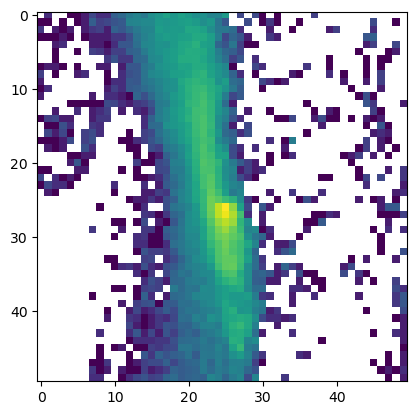

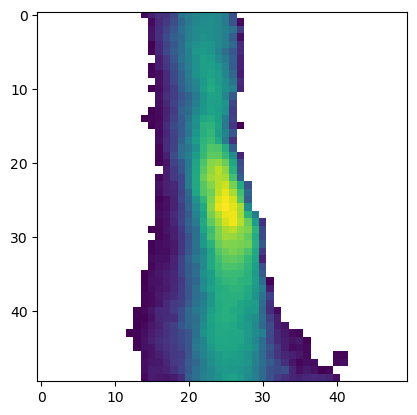

In [ ]:
t = 16#t+5
plt.imshow(np.log10(mod.preds_test.fp[t]))
plt.show()
plt.imshow(np.log10(mod.preds_test.thr[t]))
plt.show()

using UNIFORM fluxes!
USING NO UNITS TRANSFORM on the fluxes! this may have changed


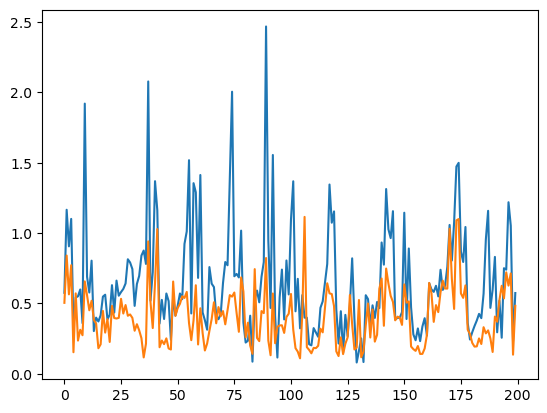

In [ ]:
# get_fluxes by default calculates the mole fraction using uniform fluxes, ie summing over the footprints
mod.get_fluxes()

window_n = 5
window_size = 200
plt.plot(mod.true_flux[window_n*window_size:(1+window_n)*window_size])
plt.plot(mod.pred_fluxes["thr"][window_n*window_size:(1+window_n)*window_size])

In [ ]:
# OR we can load and cut the actual fluxes to get realistic above-baseline concentrations

# loads the brazil map of mole fractions
brazil_mole_fractions = load_default_brazil_emissions()

# load the true footprints to use the release_lat and release_lon,
# and select the same timepoints as the testing set
true_fps = load_fps("/group/chemistry/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_2016*.nc")
true_fps = true_fps.sel(time=mod.preds_test.time)

cut_flux = cut_emissions_data(brazil_mole_fractions, true_fps, 50)
cut_flux = cut_mole_fraction.transpose([2,0,1])
# now cut_flux is in the same shape as mod.pred_fluxes["thr"], so we can plot it
mod.get_fluxes(cut_flux)

Text(0, 0.5, 'ppb')

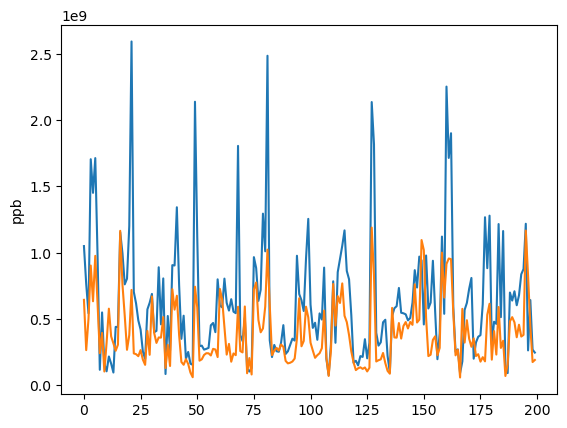

In [ ]:
window_n = 3#window_n+1
window_size = 200
plt.plot(1e9*mod.true_flux[window_n*window_size:(1+window_n)*window_size])
plt.plot(1e9*mod.pred_fluxes["thr"][window_n*window_size:(1+window_n)*window_size])
plt.ylabel("ppb")